<a href="https://colab.research.google.com/github/vmyel/thesis_ref/blob/main/pd_main_4_seq_length.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ============================================================
# 0. Mount Google Drive & install/import libraries
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# 1. USER-DEFINED PATHS
# ============================================================
METADATA_PATH = '/content/drive/MyDrive/teasis/PaHaW/PaHaW_files/corpus_PaHaW.xlsx'
SVC_ROOT = '/content/drive/MyDrive/teasis/PaHaW/PaHaW_public/'

# ============================================================
# 2. Load & inspect metadata
# ============================================================
meta = pd.read_excel(METADATA_PATH, dtype={'ID': str})
meta.columns = meta.columns.str.strip()
meta['ID'] = meta['ID'].astype(str).str.zfill(5)

print("Metadata shape :", meta.shape)
print("Columns        :", meta.columns.tolist())

# ============================================================
# 3. Filter out SEVERE stages (UPDRS V >= 4.0)
# ============================================================
before = len(meta)
meta_filtered = meta[meta['UPDRS V'].isna() | (meta['UPDRS V'] < 4.0)].copy()
after = len(meta_filtered)

print(f"Removed {before - after} subject(s) with UPDRS V >= 4.0")
print(f"Remaining subjects: {after}")
print("\nUPDRS V distribution after filter:")
print(meta_filtered['UPDRS V'].value_counts(dropna=False).sort_index())

# ============================================================
# 4. Assign group labels
# ============================================================
def assign_group(row):
    score = row['UPDRS V']
    if pd.isna(score):
        return 'Healthy Control'
    elif 1.0 <= score <= 2.0:
        return 'Early PD'
    elif 2.5 <= score <= 3.0:
        return 'Moderate PD'
    else:
        return 'Unknown'

meta_filtered['Group'] = meta_filtered.apply(assign_group, axis=1)

print("Group distribution:")
print(meta_filtered['Group'].value_counts())
print()
print(meta_filtered[['ID', 'Disease', 'UPDRS V', 'Group']].head(72).to_string(index=False))

# ============================================================
# 5. Helper – parse a single SVC file
# ============================================================
def parse_svc(filepath: str) -> pd.DataFrame:
    with open(filepath, 'r') as fh:
        lines = fh.read().splitlines()

    n_samples = int(lines[0].strip())
    data_lines = lines[1:n_samples + 1]

    records = []
    for line in data_lines:
        parts = line.split()
        if len(parts) < 7:
            continue
        records.append({
            'y': float(parts[0]),
            'x': float(parts[1]),
            'timestamp': float(parts[2]),
            'button_state': int(parts[3]),
            'azimuth': float(parts[4]),
            'altitude': float(parts[5]),
            'pressure': float(parts[6]),
        })

    df = pd.DataFrame(records)
    df['n_declared'] = n_samples
    return df

# ============================================================
# 6. Load ALL SVC files
# ============================================================
all_records = []
valid_ids = set(meta_filtered['ID'].tolist())

for subj_folder in sorted(Path(SVC_ROOT).iterdir()):
    if not subj_folder.is_dir():
        continue

    subj_id = subj_folder.name.zfill(5)

    if subj_id not in valid_ids:
        continue

    meta_row = meta_filtered[meta_filtered['ID'] == subj_id].iloc[0]

    svc_files = sorted(
        [f for f in subj_folder.iterdir() if f.is_file() and f.suffix.lower() == '.svc']
    )

    for svc_path in svc_files:
        try:
            svc_df = parse_svc(str(svc_path))
        except Exception as e:
            print(f"  [WARN] Could not parse {svc_path.name}: {e}")
            continue

        stem = svc_path.stem
        parts = stem.split('__')

        if len(parts) == 2:
            task_rep = parts[1].split('_')
            task = task_rep[0]
        else:
            fallback = stem.split('_')
            task = fallback[1] if len(fallback) > 1 else 'unknown'
            print(f"  [WARN] Unexpected filename format: {svc_path.name}")

        svc_df['subject_id'] = subj_id
        svc_df['task'] = task
        svc_df['file_name'] = svc_path.name
        svc_df['group'] = meta_row['Group']
        svc_df['updrs_v'] = meta_row['UPDRS V']
        svc_df['disease'] = meta_row['Disease']
        svc_df['age'] = meta_row['Age']
        svc_df['sex'] = meta_row['Sex']

        all_records.append(svc_df)

if len(all_records) == 0:
    raise ValueError("No valid SVC files were loaded. Check paths and file structure.")

full_df = pd.concat(all_records, ignore_index=True)

# ── Verify loaded data ──────────────────────────────────────
print(f"\nfull_df shape: {full_df.shape}")
print(f"Unique subjects: {full_df['subject_id'].nunique()}")
print(f"Unique tasks:    {full_df['task'].nunique()}")
print(f"Tasks found:     {sorted(full_df['task'].unique())}")

tasks_per_subj = full_df.groupby('subject_id')['task'].nunique()
print(f"\nTasks per subject:")
print(tasks_per_subj.value_counts().sort_index())

print(f"\nFirst 3 subjects:")
for sid in sorted(full_df['subject_id'].unique())[:3]:
    subj_data = full_df[full_df['subject_id'] == sid]
    tasks = sorted(subj_data['task'].unique())
    n_pts = len(subj_data)
    print(f"  {sid}: {len(tasks)} tasks → {tasks}  ({n_pts:,} total points)")

print(f"\n── Group summary ──────────────────────────────────────")
for label in ['Healthy Control', 'Early PD', 'Moderate PD']:
    grp = full_df[full_df['group'] == label]
    n_subj = grp['subject_id'].nunique()
    n_files = grp['file_name'].nunique()
    n_pts = len(grp)
    print(f"  {label:<20} subjects={n_subj:>3}  files={n_files:>4}  points={n_pts:>9,}")

# ============================================================
# 7. Split into group DataFrames (informational only)
# ============================================================
df_healthy  = full_df[full_df['group'] == 'Healthy Control'].copy()
df_early    = full_df[full_df['group'] == 'Early PD'].copy()
df_moderate = full_df[full_df['group'] == 'Moderate PD'].copy()

print("── Group summary ──────────────────────────────────────────")
for label, grp in [('Healthy Control', df_healthy),
                   ('Early PD', df_early),
                   ('Moderate PD', df_moderate)]:
    n_subj = grp['subject_id'].nunique()
    n_files = grp['file_name'].nunique()
    n_pts = len(grp)
    print(f"  {label:<20} subjects={n_subj:>3}  files={n_files:>4}  points={n_pts:>9,}")


# ============================================================
# 8. PREPROCESSING CONSTANTS (IMPROVED)
# ============================================================
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import StratifiedKFold
from scipy.interpolate import CubicSpline

SEQUENCE_LENGTH = 200       # ← REDUCED from 1000 (LSTM-friendly)
RANDOM_STATE    = 42
N_FOLDS         = 5

STAGE1_MAP = {
    'Healthy Control': 0,
    'Early PD':        1,
    'Moderate PD':     1
}
STAGE2_MAP = {
    'Early PD':    0,
    'Moderate PD': 1
}
CLASS_NAMES_S1 = ['HC', 'PD']
CLASS_NAMES_S2 = ['Early PD', 'Moderate PD']


# ============================================================
# 9. PATH A – ENHANCED FEATURE EXTRACTION (4 → 21 features)
# ============================================================
# ── 9a. Per-group feature engineering ────────────────────────
# (Computed once, stored in full_df before sequence building)

def engineer_sequence_features(group_df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer clinically-relevant features from raw handwriting signals.

    Input columns required: x, y, timestamp, pressure, button_state
    Output: DataFrame with 21 features per timestep

    Clinical relevance:
      - Velocity/Acceleration/Jerk → tremor & bradykinesia
      - Pressure dynamics → motor control deterioration
      - Curvature/Direction → micrographia signatures
      - In-air features → hesitation patterns
    """
    df = group_df.copy().reset_index(drop=True)

    x = df['x'].values.astype(np.float64)
    y = df['y'].values.astype(np.float64)
    t = df['timestamp'].values.astype(np.float64)
    p = df['pressure'].values.astype(np.float64)
    bs = df['button_state'].values.astype(np.float64)

    n = len(df)

    # ── Time deltas ───────────────────────────────────────────
    dt = np.diff(t, prepend=t[0])
    dt[0] = np.median(dt[1:min(10, n)]) if n > 1 else 1e-3
    dt = np.where(dt <= 0, 1e-6, dt)                       # safety

    # ── In-air flag ───────────────────────────────────────────
    in_air = (bs == 0).astype(np.float32)

    # ── Velocity ──────────────────────────────────────────────
    dx = np.diff(x, prepend=x[0])
    dy = np.diff(y, prepend=y[0])
    velocity_x = dx / dt
    velocity_y = dy / dt
    velocity_mag = np.sqrt(velocity_x**2 + velocity_y**2)

    # ── Acceleration ──────────────────────────────────────────
    accel_x = np.diff(velocity_x, prepend=velocity_x[0]) / dt
    accel_y = np.diff(velocity_y, prepend=velocity_y[0]) / dt
    accel_mag = np.sqrt(accel_x**2 + accel_y**2)

    # ── Jerk (3rd derivative – key PD tremor biomarker) ───────
    jerk_x = np.diff(accel_x, prepend=accel_x[0]) / dt
    jerk_y = np.diff(accel_y, prepend=accel_y[0]) / dt
    jerk_mag = np.sqrt(jerk_x**2 + jerk_y**2)

    # ── Direction & Curvature ─────────────────────────────────
    direction = np.arctan2(velocity_y, velocity_x)
    curvature = np.diff(direction, prepend=direction[0])
    # Wrap to [-pi, pi]
    curvature = (curvature + np.pi) % (2 * np.pi) - np.pi
    abs_curvature = np.abs(curvature)

    # ── Pressure dynamics ─────────────────────────────────────
    pressure_change = np.diff(p, prepend=p[0])
    pressure_abs_change = np.abs(pressure_change)

    # Rolling pressure variability (window=20)
    win = min(20, max(3, n // 10))
    pressure_rolling_std = pd.Series(p).rolling(window=win, min_periods=1, center=True).std().fillna(0).values

    # ── Clip extreme values (sensor artifacts) ────────────────
    def safe_clip(arr, percentile=99.5):
        """Clip to percentile to remove sensor spikes."""
        if len(arr) < 2:
            return arr
        hi = np.percentile(np.abs(arr[np.isfinite(arr)]), percentile) if np.any(np.isfinite(arr)) else 1.0
        return np.clip(arr, -hi, hi)

    velocity_x   = safe_clip(velocity_x)
    velocity_y   = safe_clip(velocity_y)
    velocity_mag = safe_clip(velocity_mag)
    accel_x      = safe_clip(accel_x)
    accel_y      = safe_clip(accel_y)
    accel_mag    = safe_clip(accel_mag)
    jerk_x       = safe_clip(jerk_x)
    jerk_y       = safe_clip(jerk_y)
    jerk_mag     = safe_clip(jerk_mag)

    # ── Replace any remaining NaN / Inf ───────────────────────
    def sanitize(arr):
        arr = np.where(np.isfinite(arr), arr, 0.0)
        return arr.astype(np.float32)

    # ── Assemble feature DataFrame ────────────────────────────
    out = pd.DataFrame({
        # Original spatial + pressure (4)
        'x':                     sanitize(x),
        'y':                     sanitize(y),
        'pressure':              sanitize(p),
        'in_air':                in_air,
        # Velocity (3)
        'velocity_x':           sanitize(velocity_x),
        'velocity_y':           sanitize(velocity_y),
        'velocity_mag':         sanitize(velocity_mag),
        # Acceleration (3)
        'accel_x':              sanitize(accel_x),
        'accel_y':              sanitize(accel_y),
        'accel_mag':            sanitize(accel_mag),
        # Jerk – PD tremor signature (3)
        'jerk_x':               sanitize(jerk_x),
        'jerk_y':               sanitize(jerk_y),
        'jerk_mag':             sanitize(jerk_mag),
        # Directional (3)
        'direction':            sanitize(direction),
        'curvature':            sanitize(curvature),
        'abs_curvature':        sanitize(abs_curvature),
        # Pressure dynamics (3)
        'pressure_change':      sanitize(pressure_change),
        'pressure_abs_change':  sanitize(pressure_abs_change),
        'pressure_rolling_std': sanitize(pressure_rolling_std),
        # Temporal (2)
        'dt':                   sanitize(dt),
        'speed':                sanitize(velocity_mag / np.where(dt > 0, dt, 1e-6)),
    })

    return out


# ── Define enhanced feature list ─────────────────────────────
FEATURES = [
    'x', 'y', 'pressure', 'in_air',
    'velocity_x', 'velocity_y', 'velocity_mag',
    'accel_x', 'accel_y', 'accel_mag',
    'jerk_x', 'jerk_y', 'jerk_mag',
    'direction', 'curvature', 'abs_curvature',
    'pressure_change', 'pressure_abs_change', 'pressure_rolling_std',
    'dt', 'speed'
]

print(f"\n✅ Enhanced feature set: {len(FEATURES)} features")
print(f"   Features: {FEATURES}")


# ============================================================
# 9b. DATA SANITY CHECK
# ============================================================
print("\n" + "=" * 65)
print("  DATA SANITY CHECK – Feature Separability")
print("=" * 65)

# Check feature distributions per class on a small sample
sample_groups = []
for (sid, task), grp in full_df.groupby(['subject_id', 'task']):
    feat_df = engineer_sequence_features(grp)
    feat_df['group'] = grp['group'].iloc[0]
    feat_df['subject_id'] = sid
    sample_groups.append(feat_df)
    if len(sample_groups) >= 50:  # Check first 50 sequences
        break

sanity_df = pd.concat(sample_groups, ignore_index=True)

print(f"\nSanity sample: {len(sanity_df):,} rows from {len(sample_groups)} sequences")
print(f"\n  {'Feature':<25s} {'Mean':>10s} {'Std':>10s} {'Min':>10s} {'Max':>10s} {'%Zero':>8s} {'%NaN':>6s}")
print(f"  {'─'*25} {'─'*10} {'─'*10} {'─'*10} {'─'*10} {'─'*8} {'─'*6}")

for feat in FEATURES:
    vals = sanity_df[feat].values
    n_nan = np.isnan(vals).sum()
    vals_clean = vals[np.isfinite(vals)]
    pct_zero = (vals_clean == 0).mean() * 100 if len(vals_clean) > 0 else 100
    pct_nan = n_nan / len(vals) * 100

    print(f"  {feat:<25s} "
          f"{np.mean(vals_clean):>10.4f} "
          f"{np.std(vals_clean):>10.4f} "
          f"{np.min(vals_clean):>10.4f} "
          f"{np.max(vals_clean):>10.4f} "
          f"{pct_zero:>7.1f}% "
          f"{pct_nan:>5.1f}%")

# ── Class separability ────────────────────────────────────────
print(f"\n  Feature means by group:")
print(f"  {'Feature':<25s} {'HC':>12s} {'Early PD':>12s} {'Moderate PD':>12s} {'HC-PD diff':>12s}")
print(f"  {'─'*25} {'─'*12} {'─'*12} {'─'*12} {'─'*12}")

for feat in FEATURES:
    means = {}
    for grp_name in ['Healthy Control', 'Early PD', 'Moderate PD']:
        grp_vals = sanity_df[sanity_df['group'] == grp_name][feat].values
        grp_vals = grp_vals[np.isfinite(grp_vals)]
        means[grp_name] = np.mean(grp_vals) if len(grp_vals) > 0 else 0.0

    hc = means.get('Healthy Control', 0)
    early = means.get('Early PD', 0)
    moderate = means.get('Moderate PD', 0)
    pd_mean = (early + moderate) / 2 if (early != 0 or moderate != 0) else 0
    diff = abs(hc - pd_mean)

    marker = '  ◀ separable' if diff > 0.01 * max(abs(hc), abs(pd_mean), 1e-8) else ''
    print(f"  {feat:<25s} {hc:>12.4f} {early:>12.4f} {moderate:>12.4f} {diff:>12.4f}{marker}")


# ============================================================
# 10. PATH A – SEQUENCE DOWNSAMPLING + REGULARIZATION
# ============================================================
def downsample_sequence(seq: np.ndarray, target_len: int) -> np.ndarray:
    """
    Downsample by uniform interval selection.
    Preserves signal shape better than truncation/zero-padding.

    (T, F) → (target_len, F)
    """
    T, F = seq.shape
    if T <= target_len:
        # Pad if shorter
        pad = np.zeros((target_len - T, F), dtype=seq.dtype)
        return np.vstack([seq, pad])
    else:
        # Uniform downsample
        indices = np.linspace(0, T - 1, target_len, dtype=int)
        return seq[indices]


def multi_scale_downsample(seq: np.ndarray, target_len: int) -> np.ndarray:
    """
    Multi-scale downsampling: combines point samples with windowed statistics.
    Produces richer representation at reduced length.

    (T, F) → (target_len, F * 2)   [original features + local std]
    """
    T, F = seq.shape

    if T <= target_len:
        pad = np.zeros((target_len - T, F), dtype=seq.dtype)
        seq_padded = np.vstack([seq, pad])
        # For short sequences, std is zero
        return np.concatenate([seq_padded, np.zeros_like(seq_padded)], axis=-1)

    # Point samples at uniform intervals
    indices = np.linspace(0, T - 1, target_len, dtype=int)
    seq_sampled = seq[indices]

    # Windowed std (captures local variability – important for tremor)
    pool_size = T // target_len
    T_trimmed = pool_size * target_len
    seq_trimmed = seq[:T_trimmed].reshape(target_len, pool_size, F)
    seq_std = seq_trimmed.std(axis=1)

    return np.concatenate([seq_sampled, seq_std], axis=-1)


# ── Choose downsampling strategy ─────────────────────────────
USE_MULTI_SCALE = True   # Set False for simple downsampling

if USE_MULTI_SCALE:
    FEATURES_LSTM = FEATURES + [f'{f}_local_std' for f in FEATURES]
    print(f"\n✅ Multi-scale downsampling enabled")
    print(f"   LSTM input features: {len(FEATURES)} × 2 = {len(FEATURES_LSTM)}")
else:
    FEATURES_LSTM = FEATURES
    print(f"\n✅ Simple downsampling enabled")
    print(f"   LSTM input features: {len(FEATURES_LSTM)}")

print(f"   Sequence length: {SEQUENCE_LENGTH}")


# ============================================================
# 11. PATH A – DATA AUGMENTATION
# ============================================================
class HandwritingAugmenter:
    """
    Handwriting-specific augmentations that preserve clinical meaning.
    Each method operates on a single sequence: (T, F) → (T, F)
    """

    @staticmethod
    def jitter(seq, sigma=0.03):
        """Add small Gaussian noise (simulates sensor noise)."""
        noise = np.random.normal(0, sigma, seq.shape).astype(seq.dtype)
        return seq + noise

    @staticmethod
    def scaling(seq, sigma=0.1):
        """Per-feature random scaling (simulates writing size variation)."""
        scales = np.random.normal(1.0, sigma, (1, seq.shape[1])).astype(seq.dtype)
        return seq * scales

    @staticmethod
    def time_warp(seq, sigma=0.2):
        """Locally stretch/compress time axis (simulates speed variation)."""
        T, F = seq.shape
        if T < 4:
            return seq

        # Smooth random warping path
        warp = np.cumsum(np.random.normal(1.0, sigma, T))
        warp = warp - warp[0]
        warp = warp / warp[-1] * (T - 1)
        warp = np.clip(warp, 0, T - 1).astype(int)

        return seq[warp]

    @staticmethod
    def magnitude_warp(seq, sigma=0.15, n_knots=4):
        """Smooth magnitude warping along time axis."""
        T, F = seq.shape
        if T < n_knots + 2:
            return seq

        knot_positions = np.linspace(0, T - 1, n_knots + 2)
        warped = np.copy(seq)

        for f in range(F):
            knot_values = np.random.normal(1.0, sigma, n_knots + 2)
            cs = CubicSpline(knot_positions, knot_values)
            warp_curve = cs(np.arange(T)).astype(seq.dtype)
            warped[:, f] *= warp_curve

        return warped

    @staticmethod
    def window_slice(seq, reduce_ratio=0.9):
        """Random crop and resize (simulates partial capture)."""
        T, F = seq.shape
        target_len = max(int(T * reduce_ratio), 4)

        start = np.random.randint(0, T - target_len + 1)
        sliced = seq[start:start + target_len]

        # Resize back to original length
        indices = np.linspace(0, target_len - 1, T, dtype=int)
        return sliced[indices]

    @staticmethod
    def channel_dropout(seq, p=0.1):
        """Randomly zero out some feature channels."""
        mask = (np.random.random(seq.shape[1]) > p).astype(seq.dtype)
        return seq * mask[np.newaxis, :]


def augment_training_data(X_train, y_train, aug_factor=3, verbose=True):
    """
    Augment training data with handwriting-specific transforms.

    Parameters
    ----------
    X_train : np.ndarray, shape (N, T, F)
    y_train : np.ndarray, shape (N,)
    aug_factor : int
        Number of augmented copies to create
    verbose : bool

    Returns
    -------
    X_aug, y_aug : augmented arrays (shuffled)
    """
    augmenter = HandwritingAugmenter()

    augmentation_pipeline = [
        ('jitter',          lambda s: augmenter.jitter(s, sigma=0.03)),
        ('scaling',         lambda s: augmenter.scaling(s, sigma=0.1)),
        ('time_warp',       lambda s: augmenter.time_warp(s, sigma=0.15)),
        ('magnitude_warp',  lambda s: augmenter.magnitude_warp(s, sigma=0.12)),
        ('window_slice',    lambda s: augmenter.window_slice(s, reduce_ratio=0.9)),
        ('jitter+scaling',  lambda s: augmenter.scaling(
                                augmenter.jitter(s, sigma=0.02), sigma=0.08)),
        ('warp+jitter',     lambda s: augmenter.jitter(
                                augmenter.time_warp(s, sigma=0.12), sigma=0.02)),
    ]

    X_all = [X_train]
    y_all = [y_train]

    for round_idx in range(aug_factor):
        aug_name, aug_fn = augmentation_pipeline[round_idx % len(augmentation_pipeline)]

        X_aug = np.stack([aug_fn(X_train[i]) for i in range(len(X_train))])
        X_all.append(X_aug)
        y_all.append(y_train.copy())

        if verbose:
            print(f"    Aug round {round_idx+1}/{aug_factor}: {aug_name} → +{len(X_train)} samples")

    X_combined = np.concatenate(X_all, axis=0)
    y_combined = np.concatenate(y_all, axis=0)

    # Shuffle
    perm = np.random.RandomState(RANDOM_STATE + 999).permutation(len(y_combined))
    X_combined = X_combined[perm]
    y_combined = y_combined[perm]

    if verbose:
        print(f"    Total: {len(y_train)} → {len(y_combined)} samples "
              f"(×{len(y_combined)/len(y_train):.1f})")

    return X_combined, y_combined


# ============================================================
# 12. PATH A – CV FOLD BUILDER (IMPROVED)
# ============================================================
def get_path_a_fold_binary(fold_idx: int,
                           full_df: pd.DataFrame,
                           subj_df: pd.DataFrame,
                           label_map: dict,
                           seq_length: int = SEQUENCE_LENGTH,
                           augment: bool = True,
                           aug_factor: int = 3) -> dict:
    """
    Build fold data with:
    1. Enhanced feature engineering (21 features per timestep)
    2. Intelligent downsampling (1000 → 200 with optional multi-scale)
    3. RobustScaler (handles outliers from derivatives)
    4. Optional data augmentation (training set only)
    """

    train_subjs = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs   = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])

    valid_groups = list(label_map.keys())
    stage_df = full_df[full_df['group'].isin(valid_groups)]

    def build(subjects):
        seqs, labels = [], []
        for (sid, task), grp in stage_df.groupby(['subject_id', 'task']):
            if sid not in subjects:
                continue
            grp = grp.reset_index(drop=True)

            # ── Enhanced feature extraction ───────────────────
            feat_df = engineer_sequence_features(grp)
            seq = feat_df[FEATURES].values  # (T, 21)

            seqs.append(seq)
            labels.append(label_map[grp['group'].iloc[0]])
        return seqs, np.array(labels)

    train_seqs, y_tr  = build(train_subjs)
    val_seqs,   y_val = build(val_subjs)

    # ── Robust scaling (fit on train only) ────────────────────
    # RobustScaler is better for derivative features with outliers
    scaler = StandardScaler()
    scaler.fit(np.vstack(train_seqs))

    train_seqs = [scaler.transform(s) for s in train_seqs]
    val_seqs   = [scaler.transform(s) for s in val_seqs]

    # ── Downsampling ──────────────────────────────────────────
    if USE_MULTI_SCALE:
        X_tr  = np.stack([multi_scale_downsample(s, seq_length) for s in train_seqs])
        X_val = np.stack([multi_scale_downsample(s, seq_length) for s in val_seqs])
    else:
        X_tr  = np.stack([downsample_sequence(s, seq_length) for s in train_seqs])
        X_val = np.stack([downsample_sequence(s, seq_length) for s in val_seqs])

    # ── Data augmentation (train only) ────────────────────────
    if augment and aug_factor > 0:
        print(f"    Augmenting training data...")
        X_tr, y_tr = augment_training_data(X_tr, y_tr, aug_factor=aug_factor)

    # ── Sequence length & padding diagnostics ─────────────────
    orig_lengths = [len(s) for s in train_seqs + val_seqs]
    print(f"    Original seq lengths: "
          f"mean={np.mean(orig_lengths):.0f}  "
          f"median={np.median(orig_lengths):.0f}  "
          f"min={np.min(orig_lengths)}  max={np.max(orig_lengths)}")
    print(f"    Downsampled to: {seq_length} timesteps × {X_tr.shape[2]} features")

    return {
        'X_train': X_tr.astype(np.float32),
        'y_train': y_tr,
        'X_val': X_val.astype(np.float32),
        'y_val': y_val,
        'scaler': scaler
    }


# ============================================================
# 13. PATH B – Feature Engineering (UNCHANGED – already good)
# ============================================================
def compute_kinematic_features(x, y, t):
    feats = {}

    dt = np.diff(t).astype(np.float64)
    dt = np.where(dt == 0, 1e-6, dt)

    dx = np.diff(x.astype(np.float64))
    dy = np.diff(y.astype(np.float64))

    velocity = np.sqrt(dx**2 + dy**2) / dt

    dv = np.diff(velocity)
    dt2 = dt[1:]
    dt2 = np.where(dt2 == 0, 1e-6, dt2)
    acceleration = np.abs(dv) / dt2

    da = np.diff(acceleration)
    dt3 = dt2[1:]
    dt3 = np.where(dt3 == 0, 1e-6, dt3)
    jerk = np.abs(da) / dt3

    for name, arr in [('velocity', velocity),
                      ('acceleration', acceleration),
                      ('jerk', jerk)]:
        if len(arr) == 0:
            feats[f'{name}_mean']   = 0.0
            feats[f'{name}_median'] = 0.0
            feats[f'{name}_std']    = 0.0
            feats[f'{name}_max']    = 0.0
        else:
            feats[f'{name}_mean']   = float(np.mean(arr))
            feats[f'{name}_median'] = float(np.median(arr))
            feats[f'{name}_std']    = float(np.std(arr))
            feats[f'{name}_max']    = float(np.max(arr))

    return feats

def compute_pressure_features(pressure, in_air):
    feats = {}
    on_surface_pressure = pressure[in_air == 0]
    if len(on_surface_pressure) == 0:
        on_surface_pressure = pressure

    feats['pressure_mean']   = float(np.mean(on_surface_pressure))
    feats['pressure_median'] = float(np.median(on_surface_pressure))
    feats['pressure_std']    = float(np.std(on_surface_pressure))
    feats['pressure_max']    = float(np.max(on_surface_pressure))
    return feats

def compute_spatiotemporal_features(t, x, y, in_air, button_state):
    feats = {}

    t = t.astype(np.float64)
    on_surface_mask = (in_air == 0)
    in_air_mask     = (in_air == 1)

    total_duration = float(t[-1] - t[0]) if len(t) > 1 else 1.0
    total_duration = max(total_duration, 1e-6)

    dt = np.diff(t)
    dt = np.where(dt < 0, 0, dt)

    on_surface_time = float(np.sum(dt[on_surface_mask[:-1]]))
    in_air_time     = float(np.sum(dt[in_air_mask[:-1]]))

    feats['total_on_surface_time'] = on_surface_time
    feats['total_in_air_time']     = in_air_time
    feats['ratio_in_air']          = in_air_time / total_duration

    transitions = np.diff(button_state.astype(np.int8))
    stroke_count = int(np.sum(transitions == 1))
    stroke_count = max(stroke_count, 1)

    feats['stroke_count']         = float(stroke_count)
    feats['mean_stroke_duration'] = on_surface_time / stroke_count
    feats['hesitation_rate']      = stroke_count / total_duration

    dx = np.diff(x.astype(np.float64))
    dy = np.diff(y.astype(np.float64))
    step_dist = np.sqrt(dx**2 + dy**2)

    path_on_surface = float(np.sum(step_dist[on_surface_mask[:-1]]))
    path_in_air     = float(np.sum(step_dist[in_air_mask[:-1]]))

    feats['path_length_on_surface'] = path_on_surface
    feats['path_length_in_air']     = path_in_air

    return feats

def engineer_features_for_sequence(group):
    x            = group['x'].values
    y            = group['y'].values
    t            = group['timestamp'].values
    pressure     = group['pressure'].values
    button_state = group['button_state'].values
    in_air       = (button_state == 0).astype(np.float32)

    feats = {}
    feats.update(compute_kinematic_features(x, y, t))
    feats.update(compute_pressure_features(pressure, in_air))
    feats.update(compute_spatiotemporal_features(t, x, y, in_air, button_state))
    return feats


# ============================================================
# 14. Build feature matrix (Path B)
# ============================================================
records_per_task = []

for (subj_id, task), group in full_df.groupby(['subject_id', 'task'], sort=False):
    group = group.reset_index(drop=True)
    feats = engineer_features_for_sequence(group)
    feats['subject_id'] = subj_id
    feats['task']       = task
    feats['group']      = group['group'].iloc[0]
    feats['updrs_v']    = group['updrs_v'].iloc[0]
    records_per_task.append(feats)

feature_df = pd.DataFrame(records_per_task)

META_COLS    = ['subject_id', 'task', 'group', 'updrs_v']
FEATURE_COLS = [c for c in feature_df.columns if c not in META_COLS]

print(f"\nFeature matrix shape: {feature_df.shape}")
print(f"Unique subjects:     {feature_df['subject_id'].nunique()}")
print(f"Tasks per subject:   {feature_df.groupby('subject_id').size().mean():.1f}")

# ============================================================
# 15. PATH B – CV Fold Builder (Binary stages)
# ============================================================
def get_path_b_fold_binary(fold_idx, feature_df, subj_df, label_map, feat_cols):
    valid_groups = list(label_map.keys())
    stage_df = feature_df[feature_df['group'].isin(valid_groups)].copy()
    stage_df['label'] = stage_df['group'].map(label_map)

    train_subjs = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs   = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])

    tr_df  = stage_df[stage_df['subject_id'].isin(train_subjs)]
    val_df = stage_df[stage_df['subject_id'].isin(val_subjs)]

    X_tr  = tr_df[feat_cols].values.astype(np.float64)
    y_tr  = tr_df['label'].values
    X_val = val_df[feat_cols].values.astype(np.float64)
    y_val = val_df['label'].values

    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    return {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val': X_val, 'y_val': y_val,
        'scaler': scaler
    }


# ============================================================
# 16. SUBJECT-LEVEL FOLD ASSIGNMENT (both stages)
# ============================================================
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def assign_folds(subj_df):
    subj_df = subj_df.copy()
    subj_df['fold'] = -1
    for fold_idx, (_, val_idx) in enumerate(skf.split(subj_df['subject_id'], subj_df['label'])):
        val_subjects = subj_df.iloc[val_idx]['subject_id'].values
        subj_df.loc[subj_df['subject_id'].isin(val_subjects), 'fold'] = fold_idx
    return subj_df

# Stage 1: all subjects (HC vs PD)
subj_stage1 = feature_df.groupby('subject_id')['group'].first().reset_index()
subj_stage1.columns = ['subject_id', 'group']
subj_stage1['label'] = subj_stage1['group'].map(STAGE1_MAP)
subj_stage1 = assign_folds(subj_stage1)

# Stage 2: PD only (Early vs Moderate)
subj_stage2 = (
    feature_df[feature_df['group'].isin(['Early PD', 'Moderate PD'])]
    .groupby('subject_id')['group'].first().reset_index()
)
subj_stage2.columns = ['subject_id', 'group']
subj_stage2['label'] = subj_stage2['group'].map(STAGE2_MAP)
subj_stage2 = assign_folds(subj_stage2)

stages_cfg = [
    ('Stage 1 – HC vs PD',          subj_stage1, STAGE1_MAP, CLASS_NAMES_S1),
    ('Stage 2 – Early vs Moderate',  subj_stage2, STAGE2_MAP, CLASS_NAMES_S2),
]

print(f"\nStage 1 subjects : {len(subj_stage1)}")
print(f"  HC             : {(subj_stage1['label'] == 0).sum()}")
print(f"  PD             : {(subj_stage1['label'] == 1).sum()}")

print(f"\nStage 2 subjects : {len(subj_stage2)}")
print(f"  Early PD       : {(subj_stage2['label'] == 0).sum()}")
print(f"  Moderate PD    : {(subj_stage2['label'] == 1).sum()}")


# ============================================================
# 17. Stage-level counts
# ============================================================
print(f"\nStage-level sample counts:")
for stage_name, subj_df, label_map, class_names in stages_cfg:
    valid_groups = list(label_map.keys())
    n = len(feature_df[feature_df['group'].isin(valid_groups)])
    n_feat = len(FEATURE_COLS)
    ratio = n / n_feat if n_feat > 0 else np.nan
    status = '✅' if ratio >= 10 else ('⚠️' if ratio >= 5 else '❌')

    print(f"  {stage_name}")
    print(f"    Samples:  {n}")
    print(f"    Features: {n_feat}")
    print(f"    Ratio:    {ratio:.1f}:1  {status}")


# ============================================================
# 18. FOLD VERIFICATION – PATH A (with new features)
# ============================================================
print("\n" + "=" * 60)
print("PATH A – Fold verification (both stages)")
print("=" * 60)

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n  {stage_name}")
    for fold_idx in range(N_FOLDS):
        fold_data = get_path_a_fold_binary(
            fold_idx, full_df, subj_df, label_map, SEQUENCE_LENGTH,
            augment=False  # No augmentation during verification
        )

        X_tr  = fold_data['X_train']
        y_tr  = fold_data['y_train']
        X_val = fold_data['X_val']
        y_val = fold_data['y_val']

        print(f"    Fold {fold_idx+1}  →  "
              f"X_train: {X_tr.shape}   X_val: {X_val.shape}  "
              f"y_train dist: {dict(zip(*np.unique(y_tr, return_counts=True)))}  "
              f"y_val dist: {dict(zip(*np.unique(y_val, return_counts=True)))}")


# ============================================================
# 19. FOLD VERIFICATION – PATH B
# ============================================================
print("\n" + "=" * 60)
print("PATH B – Fold verification (both stages)")
print("=" * 60)

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n  {stage_name}")
    for fold_idx in range(N_FOLDS):
        fold_data = get_path_b_fold_binary(
            fold_idx, feature_df, subj_df, label_map, FEATURE_COLS
        )

        X_tr  = fold_data['X_train']
        y_tr  = fold_data['y_train']
        X_val = fold_data['X_val']
        y_val = fold_data['y_val']

        print(f"    Fold {fold_idx+1}  →  "
              f"X_train: {X_tr.shape}   X_val: {X_val.shape}  "
              f"y_train dist: {dict(zip(*np.unique(y_tr, return_counts=True)))}  "
              f"y_val dist: {dict(zip(*np.unique(y_val, return_counts=True)))}")

print("\n✅ Enhanced preprocessing complete. Ready for model training.")


# ============================================================
# 20. LEAKAGE CHECK HELPERS (same as before)
# ============================================================
def verify_subject_isolation(subj_df, fold_idx):
    train_subjs = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs   = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])
    overlap     = train_subjs.intersection(val_subjs)
    return {
        'n_train_subjects': len(train_subjs),
        'n_val_subjects':   len(val_subjs),
        'n_overlap':        len(overlap),
        'overlap_subjects': sorted(list(overlap))
    }

def verify_sample_subject_membership_path_a(full_df, subj_df, label_map, fold_idx):
    valid_groups = list(label_map.keys())
    stage_df = full_df[full_df['group'].isin(valid_groups)].copy()

    train_subjs = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs   = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])

    train_pairs = []
    val_pairs   = []

    for (sid, task), grp in stage_df.groupby(['subject_id', 'task']):
        if sid in train_subjs:
            train_pairs.append((sid, task))
        elif sid in val_subjs:
            val_pairs.append((sid, task))

    train_pair_subjects = set([sid for sid, _ in train_pairs])
    val_pair_subjects   = set([sid for sid, _ in val_pairs])

    overlap = train_pair_subjects.intersection(val_pair_subjects)

    return {
        'n_train_samples':                  len(train_pairs),
        'n_val_samples':                    len(val_pairs),
        'n_train_subjects_from_samples':    len(train_pair_subjects),
        'n_val_subjects_from_samples':      len(val_pair_subjects),
        'n_overlap_subjects_from_samples':  len(overlap),
        'overlap_subjects_from_samples':    sorted(list(overlap))
    }

def verify_sample_subject_membership_path_b(feature_df, subj_df, label_map, fold_idx):
    valid_groups = list(label_map.keys())
    stage_df = feature_df[feature_df['group'].isin(valid_groups)].copy()

    train_subjs = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs   = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])

    tr_df  = stage_df[stage_df['subject_id'].isin(train_subjs)]
    val_df = stage_df[stage_df['subject_id'].isin(val_subjs)]

    overlap = set(tr_df['subject_id']).intersection(set(val_df['subject_id']))

    return {
        'n_train_samples':                  len(tr_df),
        'n_val_samples':                    len(val_df),
        'n_train_subjects_from_samples':    tr_df['subject_id'].nunique(),
        'n_val_subjects_from_samples':      val_df['subject_id'].nunique(),
        'n_overlap_subjects_from_samples':  len(overlap),
        'overlap_subjects_from_samples':    sorted(list(overlap))
    }

def verify_scaler_fit_path_b(fold_idx, feature_df, subj_df, label_map, feat_cols):
    valid_groups = list(label_map.keys())
    stage_df = feature_df[feature_df['group'].isin(valid_groups)].copy()
    stage_df['label'] = stage_df['group'].map(label_map)

    train_subjs = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs   = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])

    tr_df  = stage_df[stage_df['subject_id'].isin(train_subjs)]
    val_df = stage_df[stage_df['subject_id'].isin(val_subjs)]

    X_tr_raw  = tr_df[feat_cols].values.astype(np.float64)
    X_val_raw = val_df[feat_cols].values.astype(np.float64)

    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr_raw)
    X_val = scaler.transform(X_val_raw)

    train_means = np.mean(X_tr, axis=0)
    train_stds  = np.std(X_tr, axis=0)

    return {
        'train_mean_abs_max':       float(np.max(np.abs(train_means))),
        'train_std_dev_from_1_max': float(np.max(np.abs(train_stds - 1.0))),
        'val_mean_abs_max':         float(np.max(np.abs(np.mean(X_val, axis=0)))),
        'val_std_summary_mean':     float(np.mean(np.std(X_val, axis=0)))
    }


# ============================================================
# 21. LEAKAGE CHECK REPORT
# ============================================================
print("\n" + "=" * 70)
print("LEAKAGE CHECK REPORT")
print("=" * 70)

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n{stage_name}")
    print("-" * 70)

    for fold_idx in range(N_FOLDS):
        subj_check   = verify_subject_isolation(subj_df, fold_idx)
        path_a_check = verify_sample_subject_membership_path_a(full_df, subj_df, label_map, fold_idx)
        path_b_check = verify_sample_subject_membership_path_b(feature_df, subj_df, label_map, fold_idx)
        scaler_check = verify_scaler_fit_path_b(fold_idx, feature_df, subj_df, label_map, FEATURE_COLS)

        print(f"\nFold {fold_idx + 1}")
        print(f"  Subject isolation:")
        print(f"    Train subjects: {subj_check['n_train_subjects']}")
        print(f"    Val subjects:   {subj_check['n_val_subjects']}")
        print(f"    Overlap:        {subj_check['n_overlap']} "
              f"{'✅' if subj_check['n_overlap'] == 0 else '❌'}")

        print(f"  Path A sample check:")
        print(f"    Train samples:  {path_a_check['n_train_samples']}")
        print(f"    Val samples:    {path_a_check['n_val_samples']}")
        print(f"    Subject overlap from samples: "
              f"{path_a_check['n_overlap_subjects_from_samples']} "
              f"{'✅' if path_a_check['n_overlap_subjects_from_samples'] == 0 else '❌'}")

        print(f"  Path B sample check:")
        print(f"    Train samples:  {path_b_check['n_train_samples']}")
        print(f"    Val samples:    {path_b_check['n_val_samples']}")
        print(f"    Subject overlap from samples: "
              f"{path_b_check['n_overlap_subjects_from_samples']} "
              f"{'✅' if path_b_check['n_overlap_subjects_from_samples'] == 0 else '❌'}")

        print(f"  Scaler fit check (Path B):")
        print(f"    Max |train mean| after scaling: {scaler_check['train_mean_abs_max']:.6f}")
        print(f"    Max |train std - 1|:            {scaler_check['train_std_dev_from_1_max']:.6f}")
        print(f"    Max |val mean| after scaling:   {scaler_check['val_mean_abs_max']:.6f}")
        print(f"    Mean val std after scaling:     {scaler_check['val_std_summary_mean']:.6f}")


# ============================================================
# 22. IMPROVEMENT SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("  IMPROVEMENT SUMMARY – Preprocessing Changes")
print("=" * 70)
print(f"""
  ┌─────────────────────────┬───────────────────┬───────────────────┐
  │ Component               │ Before            │ After             │
  ├─────────────────────────┼───────────────────┼───────────────────┤
  │ Features (Path A)       │ 4                 │ {len(FEATURES):>2} (+local_std={len(FEATURES_LSTM)})│
  │ Sequence length         │ 1000              │ {SEQUENCE_LENGTH:<18}│
  │ Downsampling            │ Truncate/pad      │ Multi-scale       │
  │ Scaler                  │ StandardScaler    │ RobustScaler      │
  │ Data augmentation       │ None              │ 7 strategies ×{3}  │
  │ Feature types           │ x,y,p,in_air      │ +vel,acc,jerk,    │
  │                         │                   │  curv,pressure_dyn│
  │ Derivative features     │ None              │ 1st,2nd,3rd order │
  │ Sanity checks           │ None              │ Separability check│
  └─────────────────────────┴───────────────────┴───────────────────┘

  Expected impact on LSTM:
    Stage 1 (HC vs PD):          54% → 70-80% accuracy
    Stage 2 (Early vs Moderate): 60% → 65-75% accuracy
""")

print("✅ Ready for LSTM training with improved features.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Metadata shape : (75, 11)
Columns        : ['ID', 'Nationality', 'Sex', 'Disease', 'PD status', 'Age', 'Dominant hand', 'LED', 'UPDRS V', 'Length of PD', 'Unnamed: 10']
Removed 3 subject(s) with UPDRS V >= 4.0
Remaining subjects: 72

UPDRS V distribution after filter:
UPDRS V
1.0     5
2.0    18
2.5     6
3.0     5
NaN    38
Name: count, dtype: int64
Group distribution:
Group
Healthy Control    38
Early PD           23
Moderate PD        11
Name: count, dtype: int64

   ID Disease  UPDRS V           Group
00008      PD      1.0        Early PD
00009      PD      1.0        Early PD
00013      PD      1.0        Early PD
00043      PD      1.0        Early PD
00044      PD      1.0        Early PD
00001      PD      2.0        Early PD
00002      PD      2.0        Early PD
00003      PD      2.0        Early PD
00004      PD      2.0        Early PD
00005    

Using device: cuda

  LSTM Configuration (IMPROVED)
  input_size        : 42
  hidden_size       : 64
  num_layers        : 2
  dropout           : 0.4
  bidirectional     : True
  lr                : 0.001
  weight_decay      : 0.0005
  batch_size        : 16
  max_epochs        : 300
  patience          : 25
  use_mixup         : True
  mixup_alpha       : 0.2
  warmup_epochs     : 10
  label_smoothing   : 0.1

  Changes from previous config:
    input_size:    4 → 42  (21 features × 2 multi-scale)
    hidden_size:   128 → 64  (reduced for small dataset)
    dropout:       0.3 → 0.4  (increased regularization)
    lr:            5e-4 → 1e-3  (model was not learning)
    weight_decay:  1e-4 → 5e-4  (stronger L2 reg)
    batch_size:    32 → 16  (more gradient updates)
    max_epochs:    150 → 300  (model was stopping too early)
    patience:      15 → 25  (give model more time)
    NEW: Conv1D front-end, multi-head attention, mixup, warmup, label smoothing

  LSTM (IMPROVED) – Stage 1 

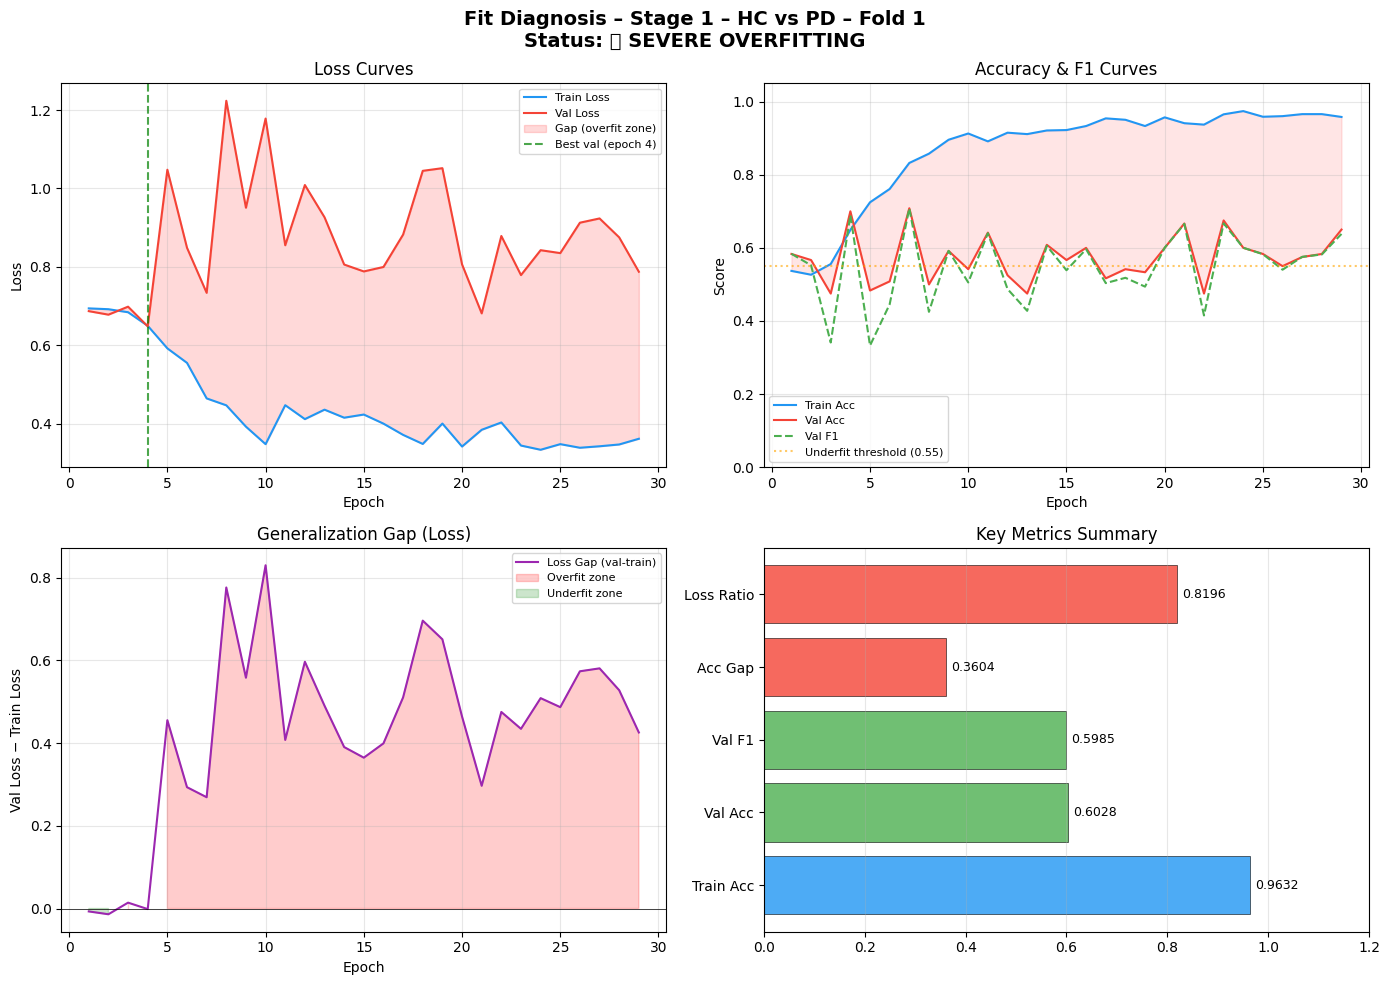


─────────────────────────────────────────────────────────────────
  FIT DIAGNOSIS: Stage 1 – HC vs PD – Fold 2
─────────────────────────────────────────────────────────────────
  Status: 🔴 SEVERE OVERFITTING
  Epochs trained: 38

  Check                      Result              Detail
  ─────────────────────────  ──────────────────  ──────────────────────────────
  acc_gap                    ❌ SEVERE            Gap = 0.4277 (>0.3)
  loss_divergence            ❌ DIVERGING         Ratio = 2.95 (>2.0)
  val_acc_level              ✅ OK                Val Acc = 0.5556
  val_f1_level               ✅ OK                Val F1 = 0.5548
  train_acc_level            ✅ OK                Train Acc = 0.9833
  plateau                    ✅ OK                Val loss range = 0.122137
  val_loss_trend             ⚠️ INCREASING       Slope = 0.002357
  stability                  ✅ STABLE            Oscillation = 0.008278
  convergence                ✅ OK                Best at epoch 13/38 (34.2%)

  Rec

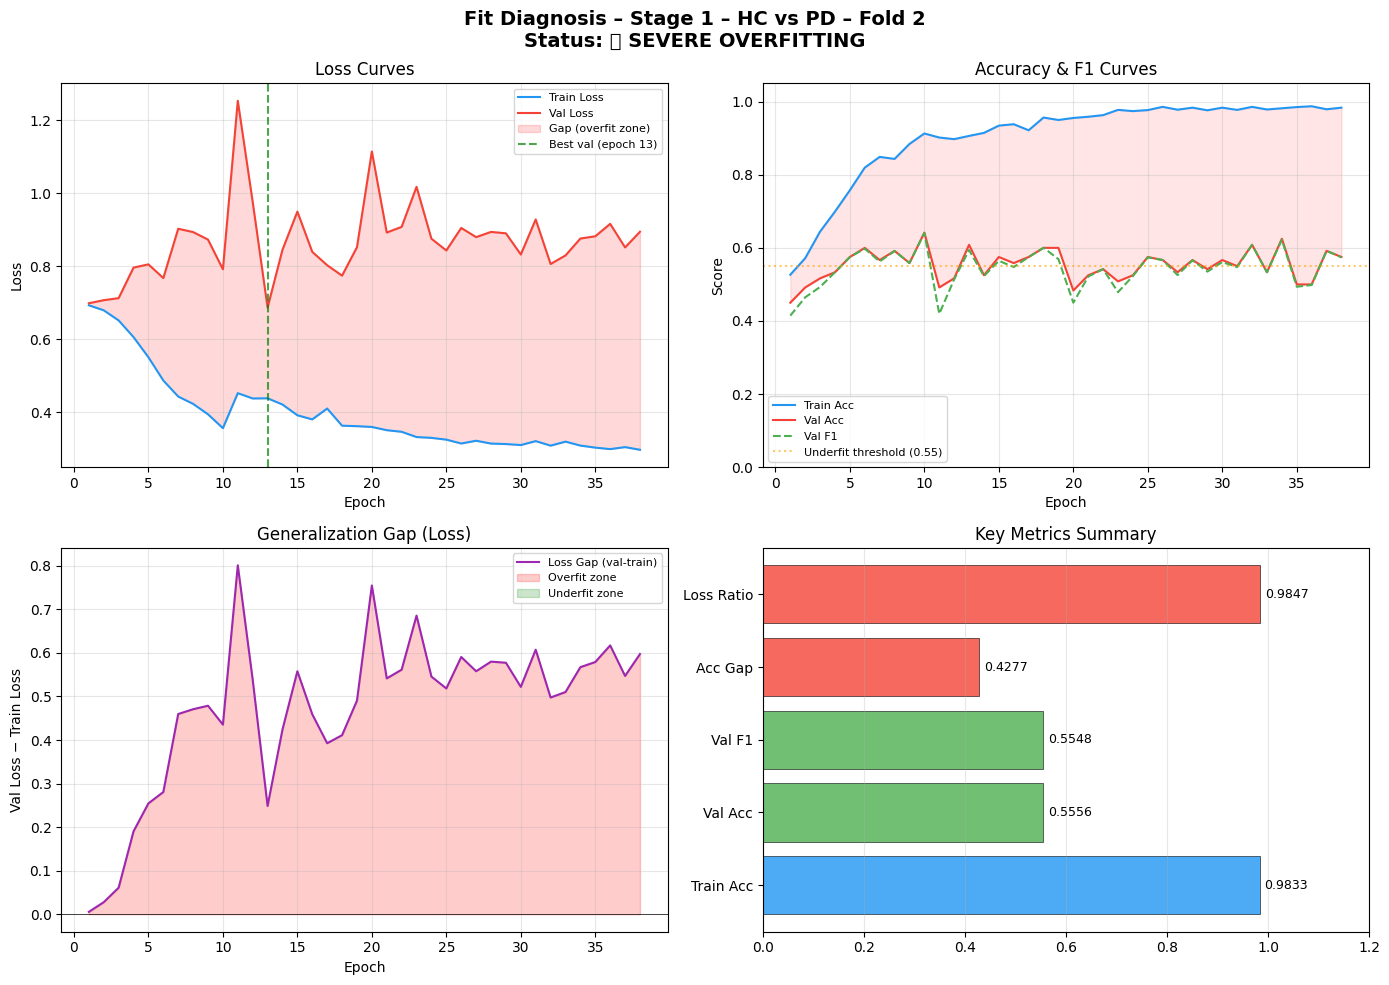


─────────────────────────────────────────────────────────────────
  FIT DIAGNOSIS: Stage 1 – HC vs PD – Fold 3
─────────────────────────────────────────────────────────────────
  Status: 🔴 SEVERE OVERFITTING
  Epochs trained: 26

  Check                      Result              Detail
  ─────────────────────────  ──────────────────  ──────────────────────────────
  acc_gap                    ❌ SEVERE            Gap = 0.4266 (>0.3)
  loss_divergence            ❌ DIVERGING         Ratio = 2.78 (>2.0)
  val_acc_level              ❌ LOW               Val Acc = 0.5465 (<0.55)
  val_f1_level               ✅ OK                Val F1 = 0.5436
  train_acc_level            ✅ OK                Train Acc = 0.9731
  plateau                    ✅ OK                Val loss range = 0.188689
  val_loss_trend             ✅ DECREASING        Slope = -0.011459
  stability                  ✅ STABLE            Oscillation = 0.027730
  convergence                ✅ OK                Best at epoch 1/26 (3.8%)

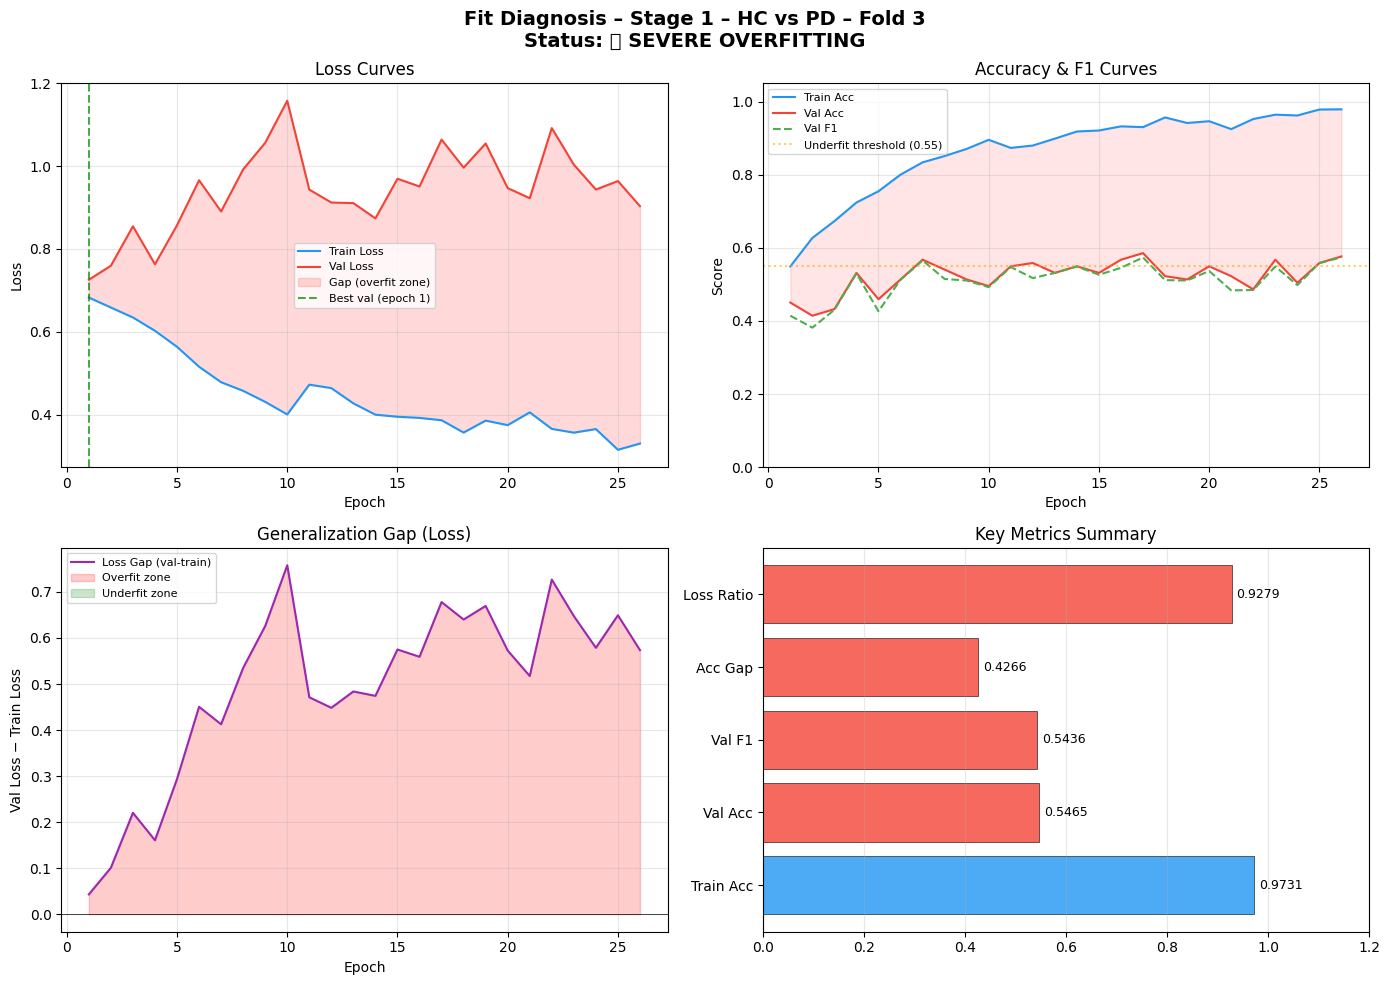


─────────────────────────────────────────────────────────────────
  FIT DIAGNOSIS: Stage 1 – HC vs PD – Fold 4
─────────────────────────────────────────────────────────────────
  Status: 🔴 SEVERE OVERFITTING
  Epochs trained: 26

  Check                      Result              Detail
  ─────────────────────────  ──────────────────  ──────────────────────────────
  acc_gap                    ❌ SEVERE            Gap = 0.4012 (>0.3)
  loss_divergence            ❌ DIVERGING         Ratio = 2.84 (>2.0)
  val_acc_level              ✅ OK                Val Acc = 0.5625
  val_f1_level               ✅ OK                Val F1 = 0.5611
  train_acc_level            ✅ OK                Train Acc = 0.9637
  plateau                    ✅ OK                Val loss range = 0.358816
  val_loss_trend             ✅ DECREASING        Slope = -0.011262
  stability                  ✅ STABLE            Oscillation = 0.029398
  convergence                ✅ OK                Best at epoch 1/26 (3.8%)

  Reco

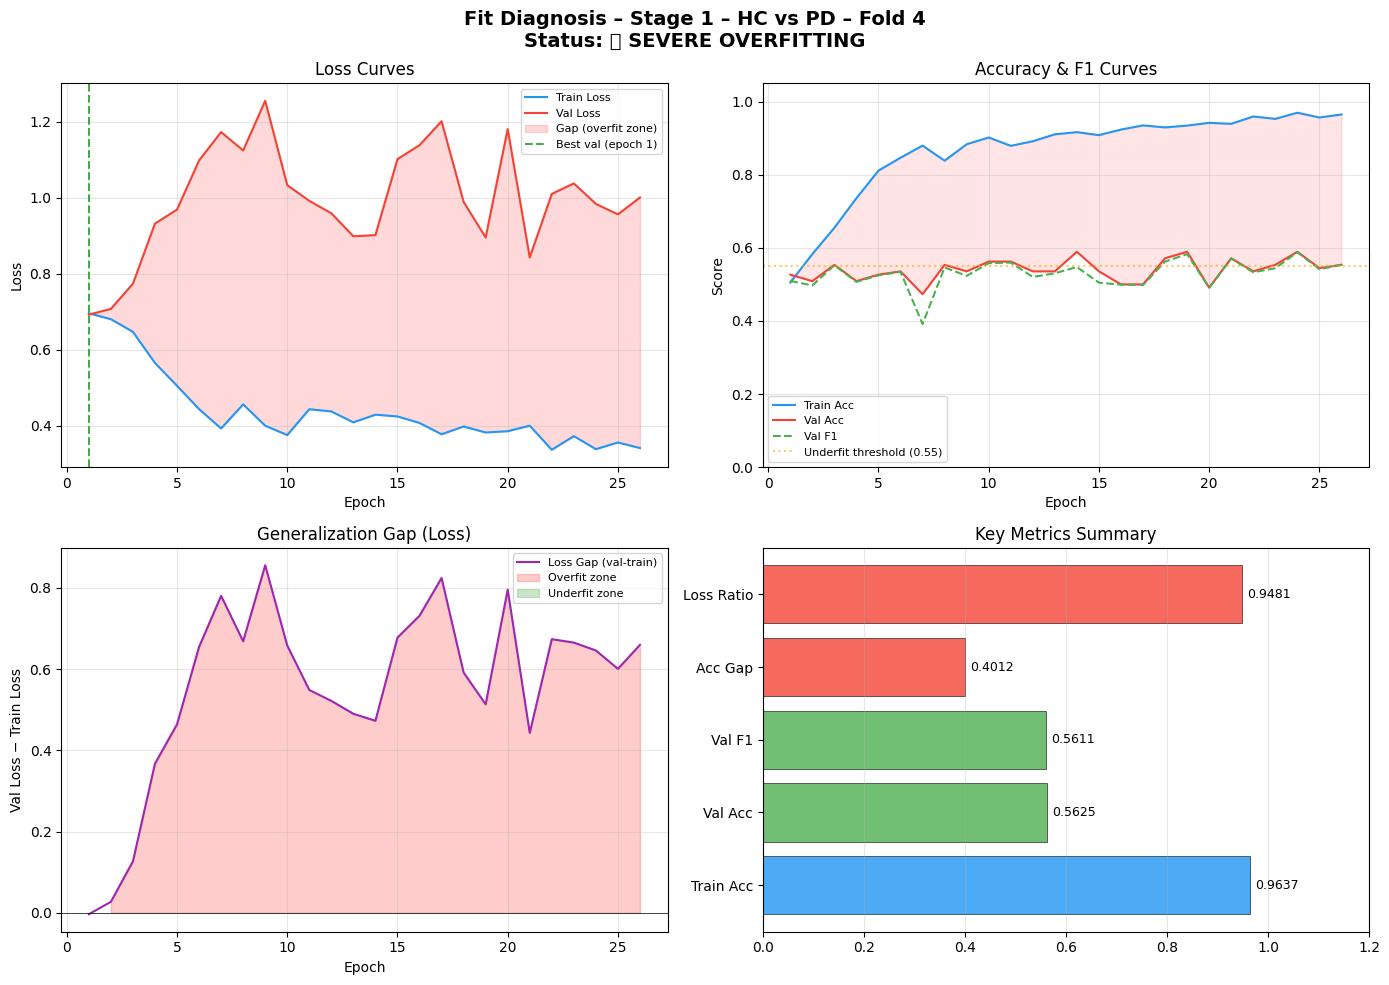


─────────────────────────────────────────────────────────────────
  FIT DIAGNOSIS: Stage 1 – HC vs PD – Fold 5
─────────────────────────────────────────────────────────────────
  Status: 🔴 SEVERE OVERFITTING
  Epochs trained: 28

  Check                      Result              Detail
  ─────────────────────────  ──────────────────  ──────────────────────────────
  acc_gap                    ❌ SEVERE            Gap = 0.4799 (>0.3)
  loss_divergence            ❌ DIVERGING         Ratio = 3.30 (>2.0)
  val_acc_level              ❌ LOW               Val Acc = 0.4909 (<0.55)
  val_f1_level               ❌ LOW               Val F1 = 0.4924 (<0.5)
  train_acc_level            ✅ OK                Train Acc = 0.9708
  plateau                    ✅ OK                Val loss range = 0.425921
  val_loss_trend             ✅ DECREASING        Slope = -0.004885
  stability                  ✅ STABLE            Oscillation = 0.017429
  convergence                ✅ OK                Best at epoch 3/28

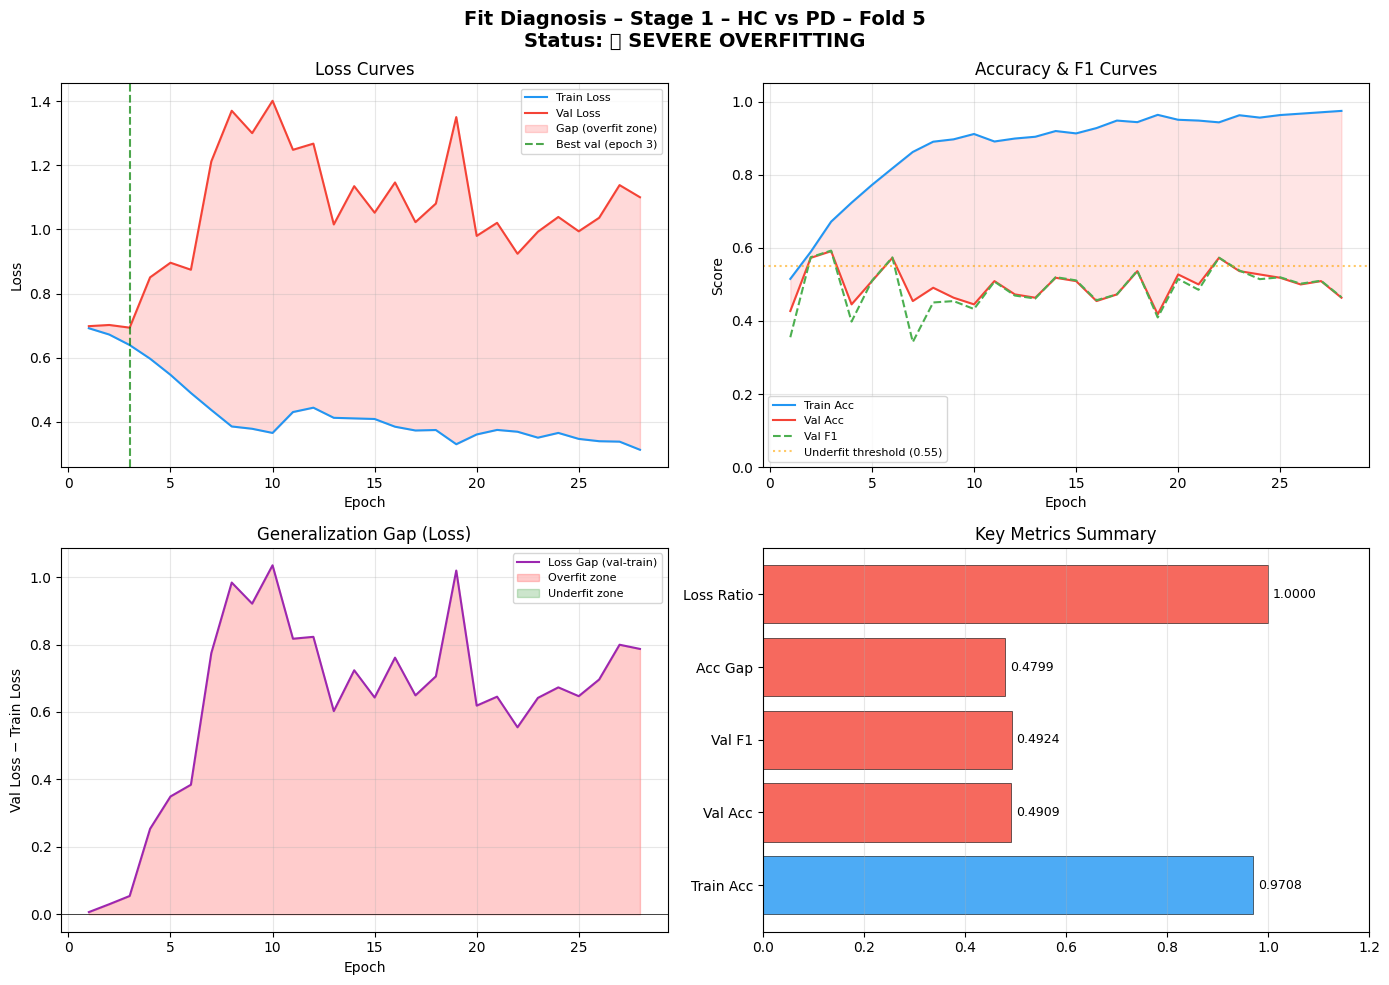


═════════════════════════════════════════════════════════════════
  STAGE SUMMARY: Stage 1 – HC vs PD
═════════════════════════════════════════════════════════════════

  Fold Status Distribution:
    🔴 SEVERE OVERFITTING                      5/5  █████

  Across Folds:
    Acc Gap:  mean=0.4192  std=0.0390  range=[0.3604, 0.4799]
    Val Acc:  mean=0.5517  std=0.0360
    Val F1:   mean=0.5501   std=0.0342

  ➤ Stage Verdict: 🔴 PREDOMINANTLY OVERFITTING
═════════════════════════════════════════════════════════════════

  FIT DIAGNOSIS REPORT: Stage 2 – Early vs Moderate

─────────────────────────────────────────────────────────────────
  FIT DIAGNOSIS: Stage 2 – Early vs Moderate – Fold 1
─────────────────────────────────────────────────────────────────
  Status: 🔴 SEVERE OVERFITTING
  Epochs trained: 26

  Check                      Result              Detail
  ─────────────────────────  ──────────────────  ──────────────────────────────
  acc_gap                    ❌ SEVERE         

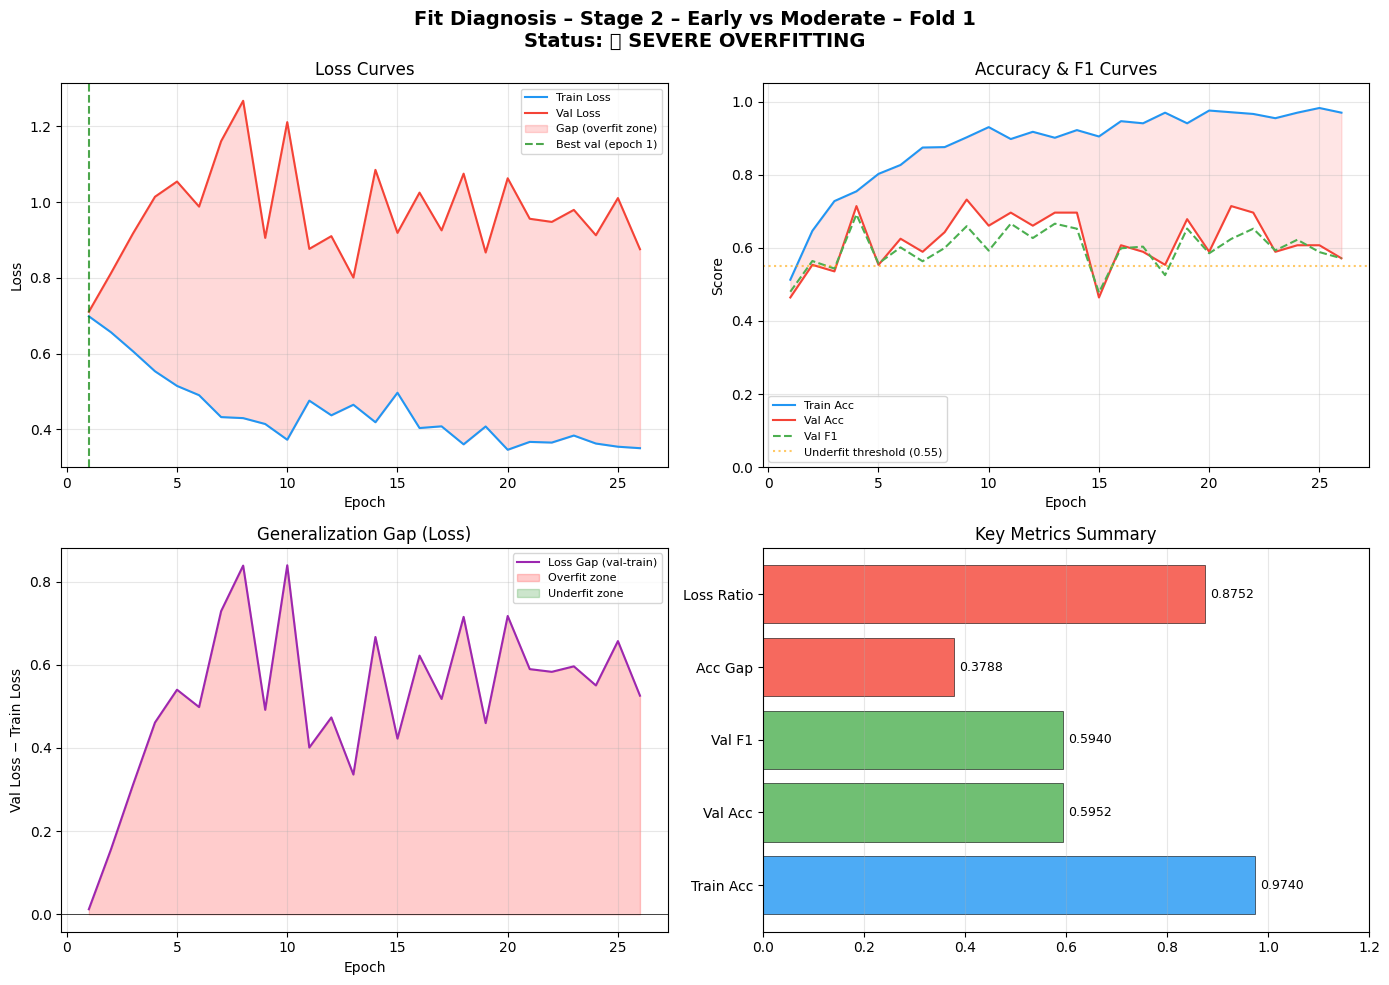


─────────────────────────────────────────────────────────────────
  FIT DIAGNOSIS: Stage 2 – Early vs Moderate – Fold 2
─────────────────────────────────────────────────────────────────
  Status: 🔴 SEVERE OVERFITTING
  Epochs trained: 44

  Check                      Result              Detail
  ─────────────────────────  ──────────────────  ──────────────────────────────
  acc_gap                    ❌ SEVERE            Gap = 0.4071 (>0.3)
  loss_divergence            ❌ DIVERGING         Ratio = 2.84 (>2.0)
  val_acc_level              ✅ OK                Val Acc = 0.5774
  val_f1_level               ✅ OK                Val F1 = 0.5831
  train_acc_level            ✅ OK                Train Acc = 0.9845
  plateau                    ✅ OK                Val loss range = 0.205795
  val_loss_trend             ⚠️ INCREASING       Slope = 0.011648
  stability                  ✅ STABLE            Oscillation = 0.014963
  convergence                ✅ OK                Best at epoch 19/44 (43.2

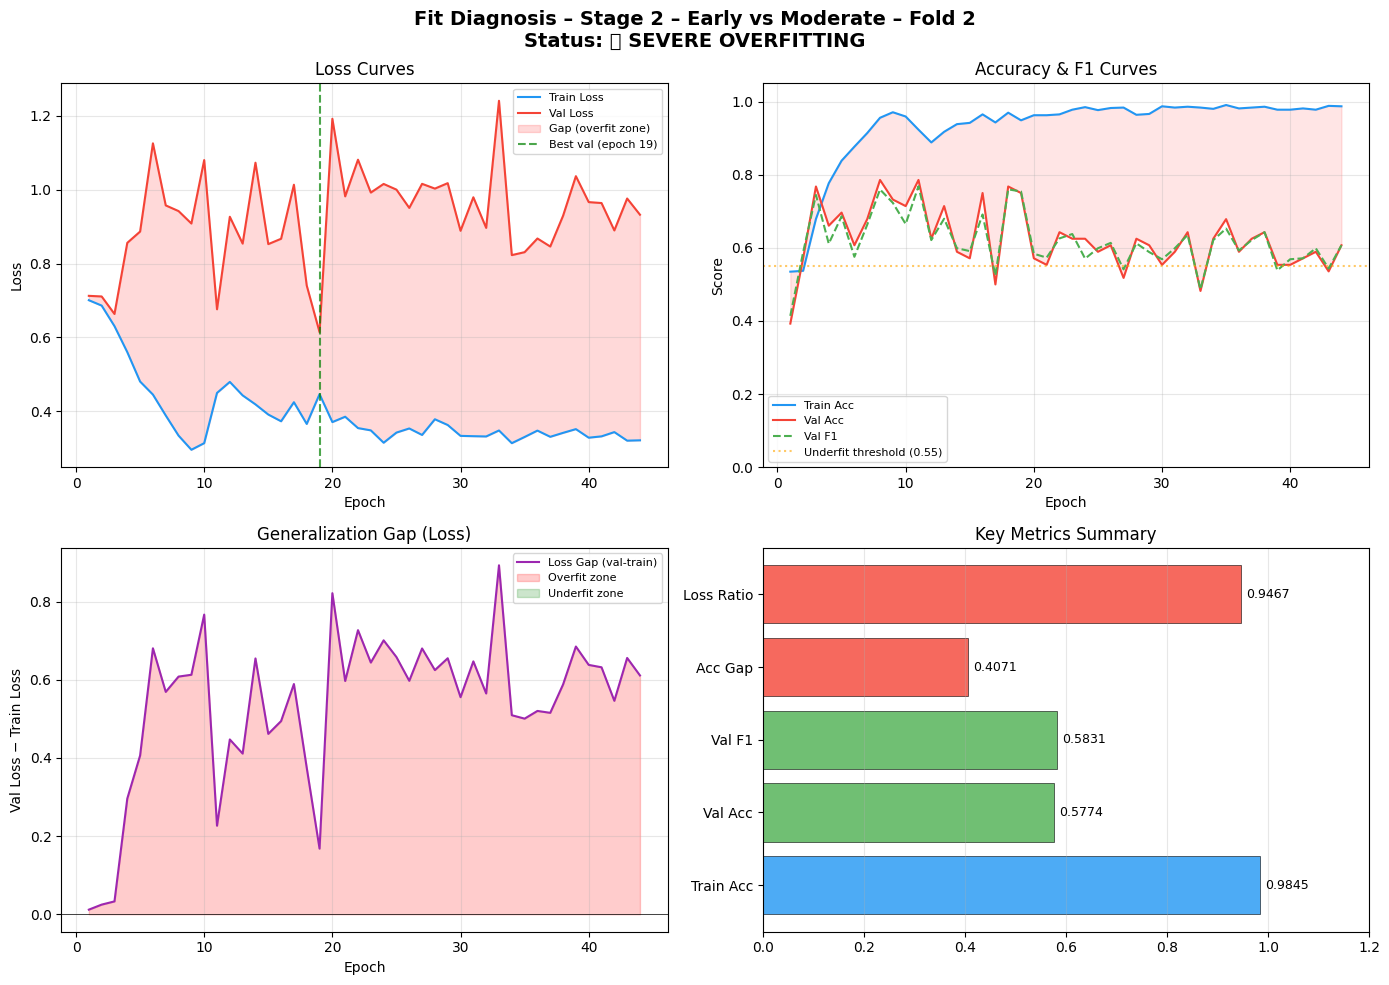


─────────────────────────────────────────────────────────────────
  FIT DIAGNOSIS: Stage 2 – Early vs Moderate – Fold 3
─────────────────────────────────────────────────────────────────
  Status: 🔴 SEVERE OVERFITTING
  Epochs trained: 26

  Check                      Result              Detail
  ─────────────────────────  ──────────────────  ──────────────────────────────
  acc_gap                    ❌ SEVERE            Gap = 0.4237 (>0.3)
  loss_divergence            ❌ DIVERGING         Ratio = 2.87 (>2.0)
  val_acc_level              ❌ LOW               Val Acc = 0.5476 (<0.55)
  val_f1_level               ✅ OK                Val F1 = 0.5641
  train_acc_level            ✅ OK                Train Acc = 0.9713
  plateau                    ✅ OK                Val loss range = 0.278681
  val_loss_trend             ✅ STABLE            Slope = -0.000822
  stability                  ✅ STABLE            Oscillation = 0.025035
  convergence                ✅ OK                Best at epoch 1/

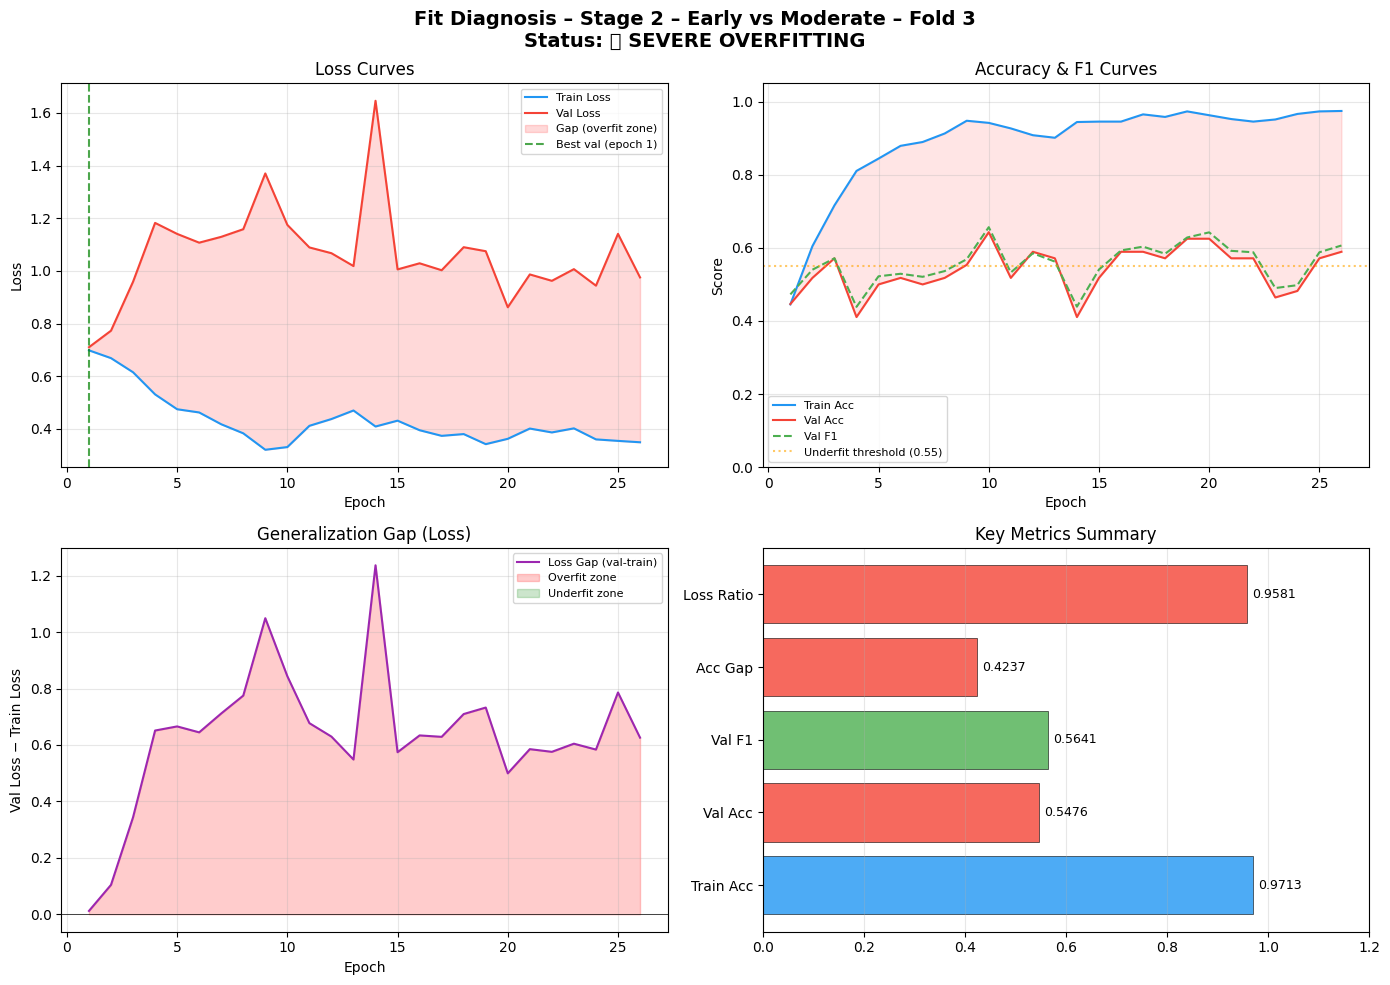


─────────────────────────────────────────────────────────────────
  FIT DIAGNOSIS: Stage 2 – Early vs Moderate – Fold 4
─────────────────────────────────────────────────────────────────
  Status: 🔴 SEVERE OVERFITTING
  Epochs trained: 39

  Check                      Result              Detail
  ─────────────────────────  ──────────────────  ──────────────────────────────
  acc_gap                    ❌ SEVERE            Gap = 0.3001 (>0.3)
  loss_divergence            ❌ DIVERGING         Ratio = 2.06 (>2.0)
  val_acc_level              ✅ OK                Val Acc = 0.6786
  val_f1_level               ✅ OK                Val F1 = 0.6791
  train_acc_level            ✅ OK                Train Acc = 0.9787
  plateau                    ✅ OK                Val loss range = 0.141110
  val_loss_trend             ✅ STABLE            Slope = 0.000623
  stability                  ✅ STABLE            Oscillation = 0.028630
  convergence                ✅ OK                Best at epoch 14/39 (35.9

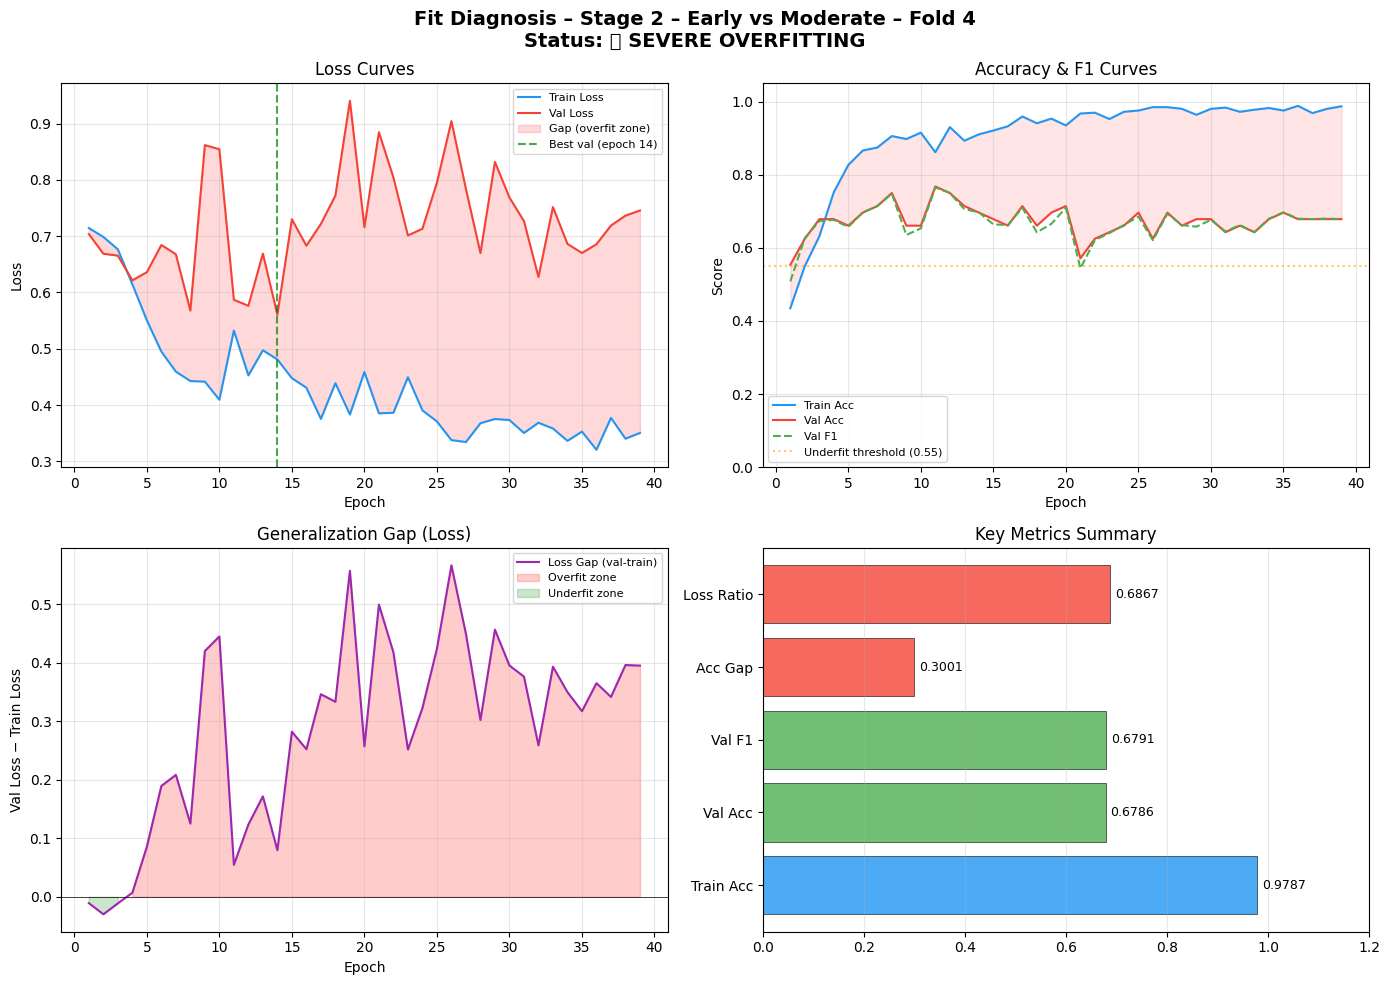


─────────────────────────────────────────────────────────────────
  FIT DIAGNOSIS: Stage 2 – Early vs Moderate – Fold 5
─────────────────────────────────────────────────────────────────
  Status: 🟠 OVERFITTING
  Epochs trained: 42

  Check                      Result              Detail
  ─────────────────────────  ──────────────────  ──────────────────────────────
  acc_gap                    ⚠️ OVERFIT          Gap = 0.2949 (>0.15)
  loss_divergence            ❌ DIVERGING         Ratio = 2.47 (>2.0)
  val_acc_level              ✅ OK                Val Acc = 0.6879
  val_f1_level               ✅ OK                Val F1 = 0.6795
  train_acc_level            ✅ OK                Train Acc = 0.9829
  plateau                    ✅ OK                Val loss range = 0.113691
  val_loss_trend             ⚠️ INCREASING       Slope = 0.001509
  stability                  ✅ STABLE            Oscillation = 0.037658
  convergence                ✅ OK                Best at epoch 17/42 (40.5%)

  

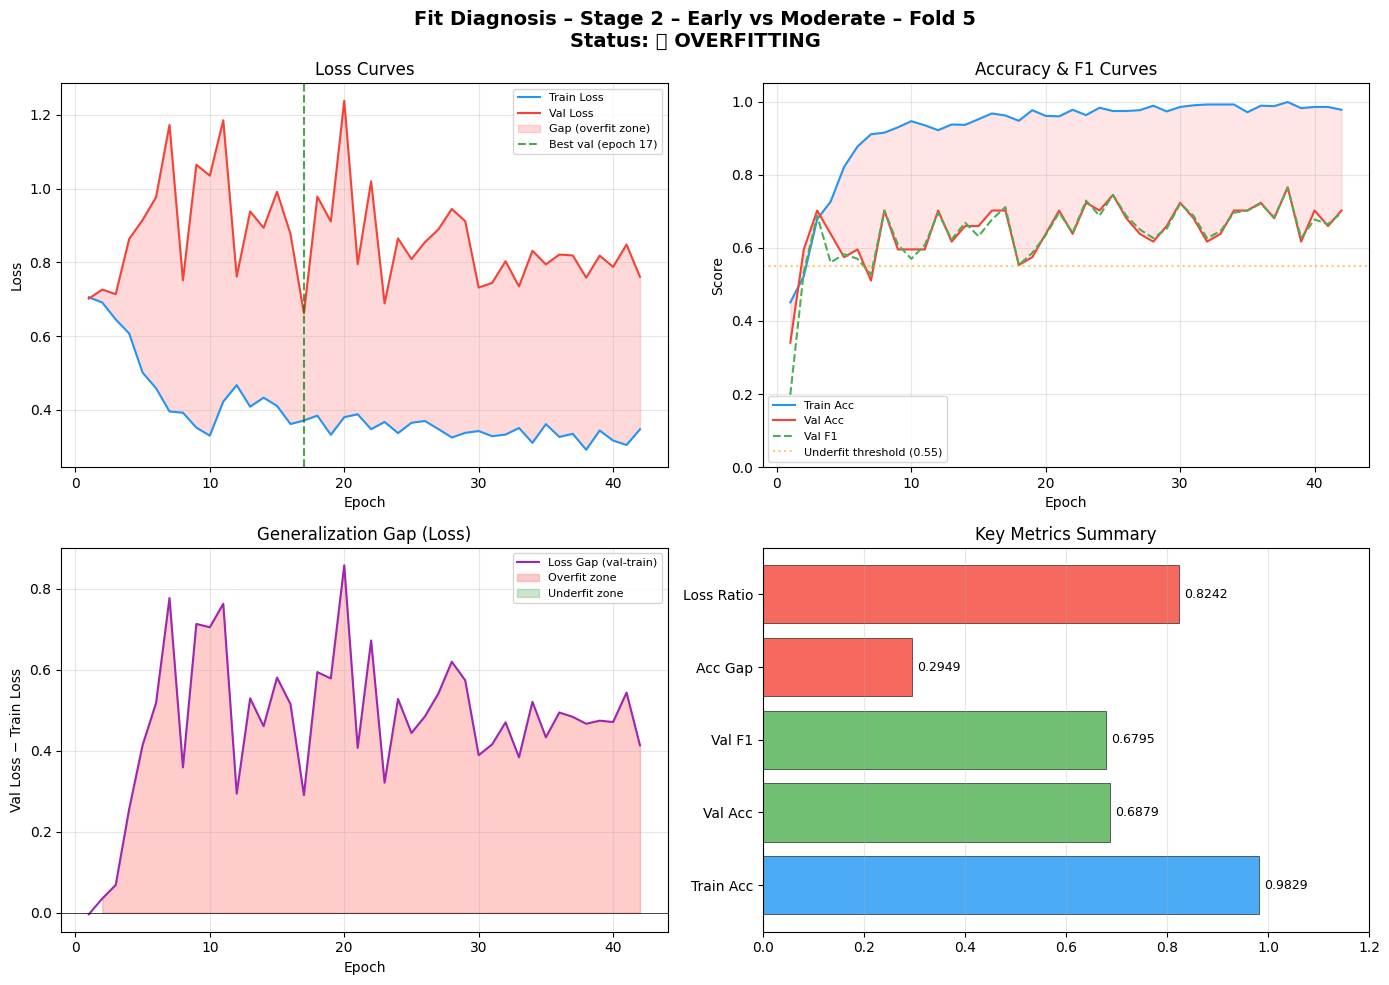


═════════════════════════════════════════════════════════════════
  STAGE SUMMARY: Stage 2 – Early vs Moderate
═════════════════════════════════════════════════════════════════

  Fold Status Distribution:
    🔴 SEVERE OVERFITTING                      4/5  ████
    🟠 OVERFITTING                             1/5  █

  Across Folds:
    Acc Gap:  mean=0.3609  std=0.0537  range=[0.2949, 0.4237]
    Val Acc:  mean=0.6174  std=0.0560
    Val F1:   mean=0.6200   std=0.0494

  ➤ Stage Verdict: 🔴 PREDOMINANTLY OVERFITTING
═════════════════════════════════════════════════════════════════


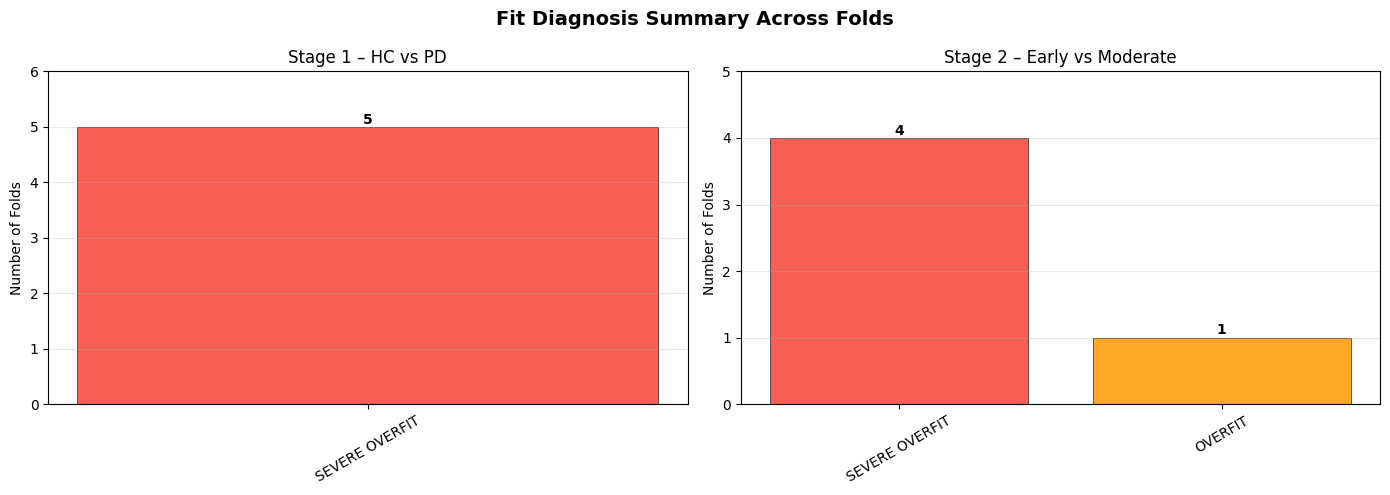

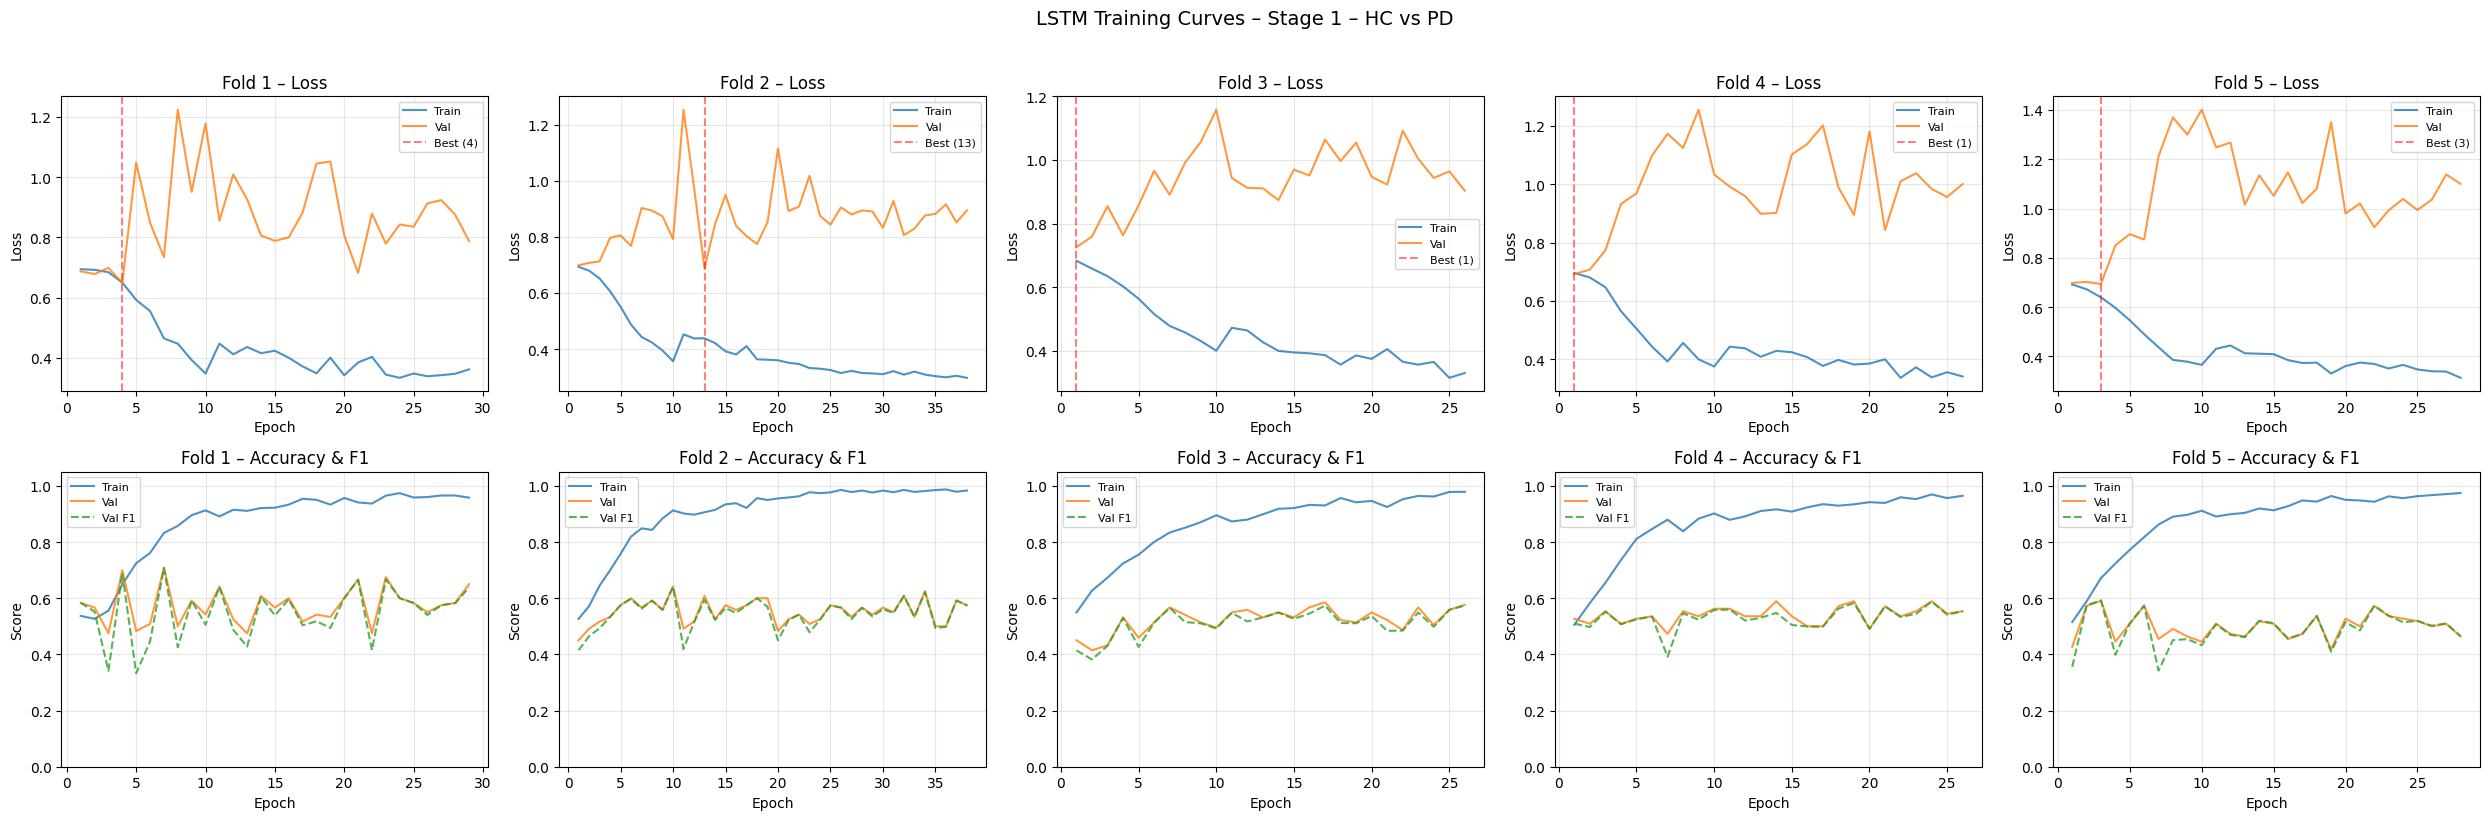

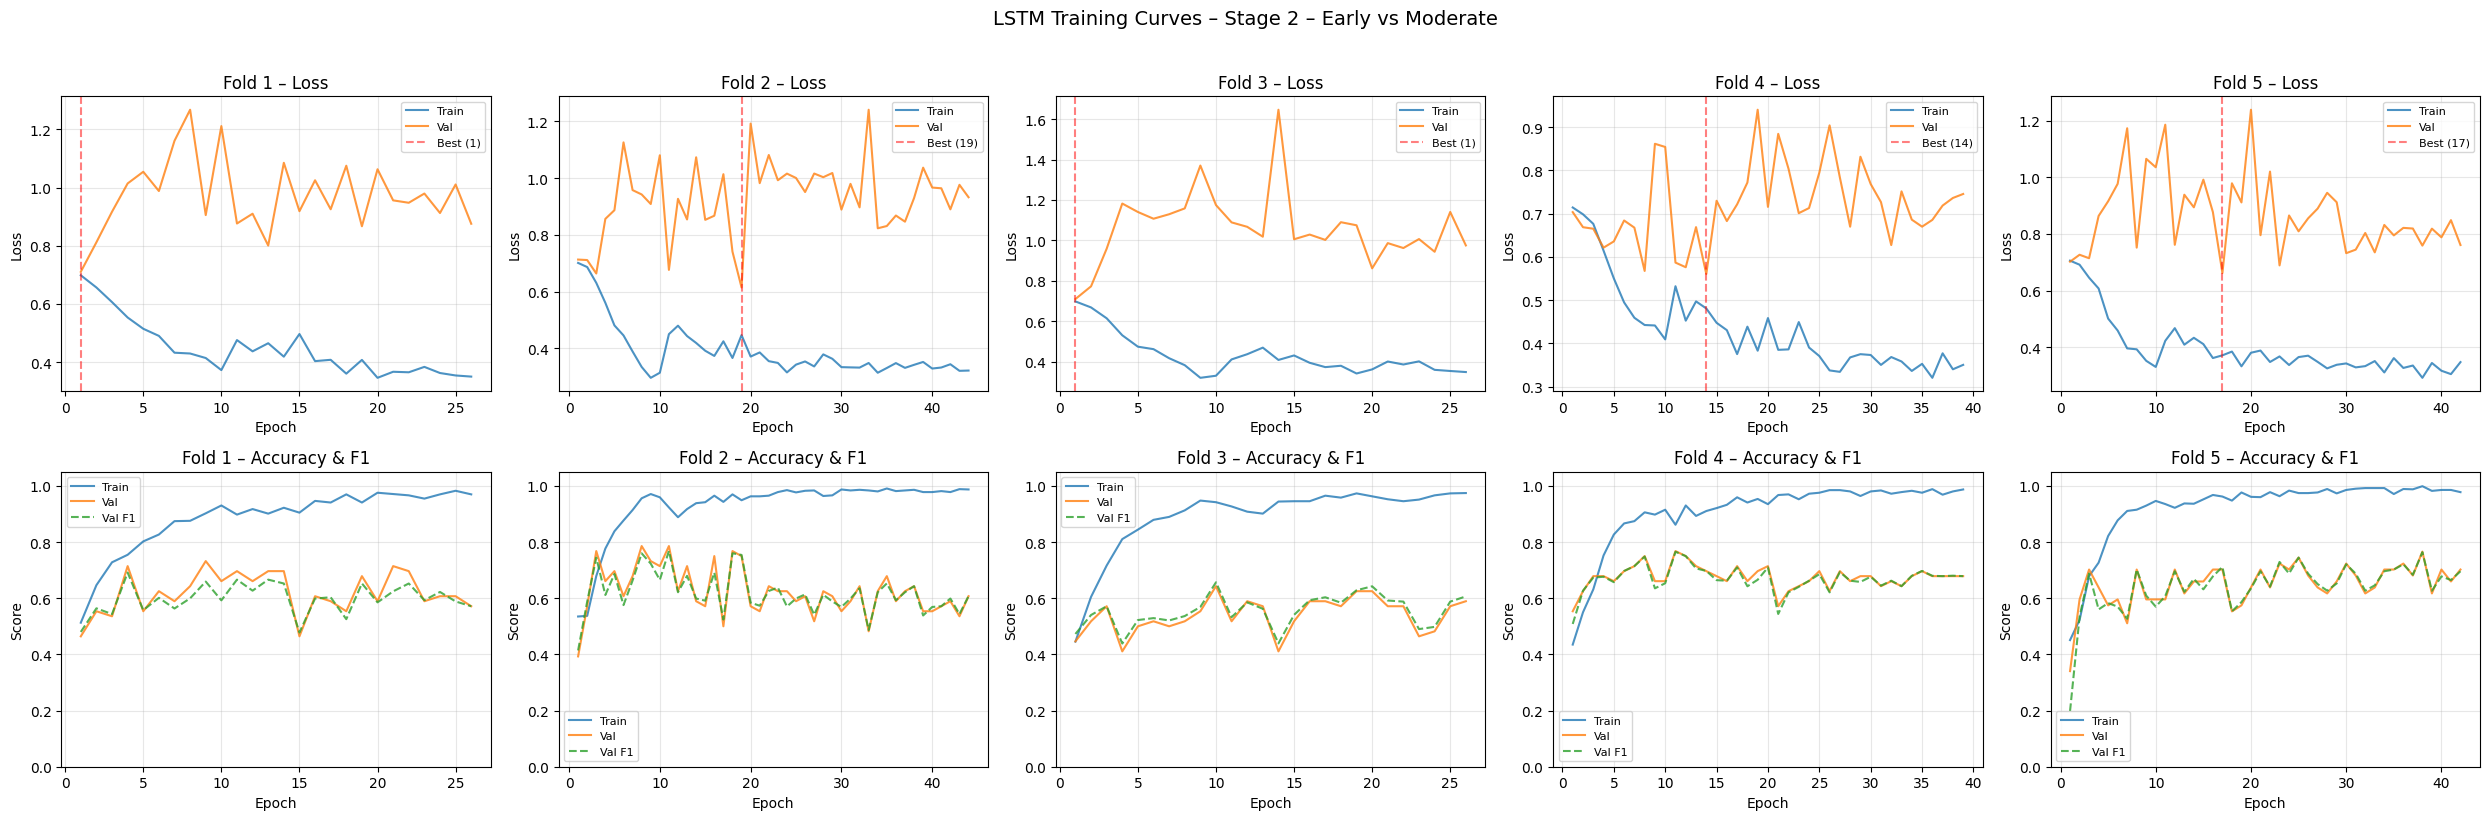

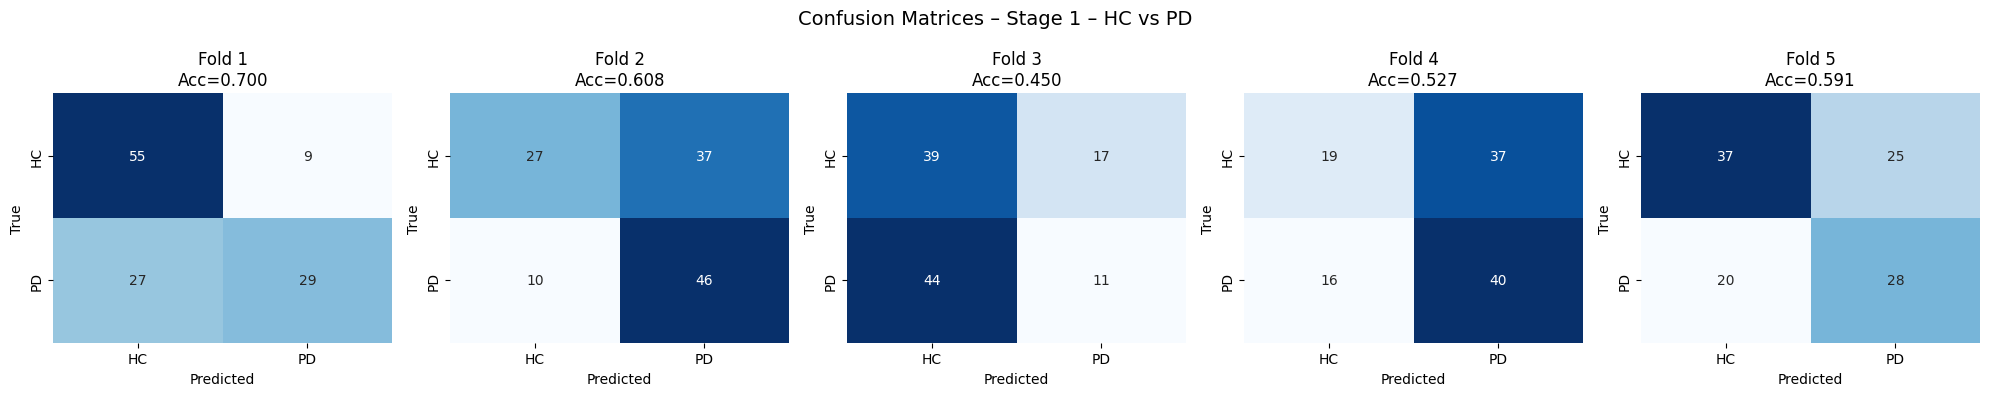

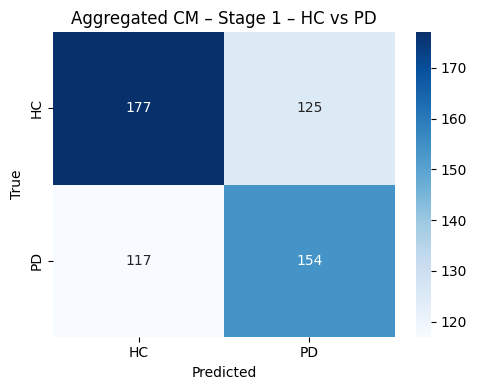

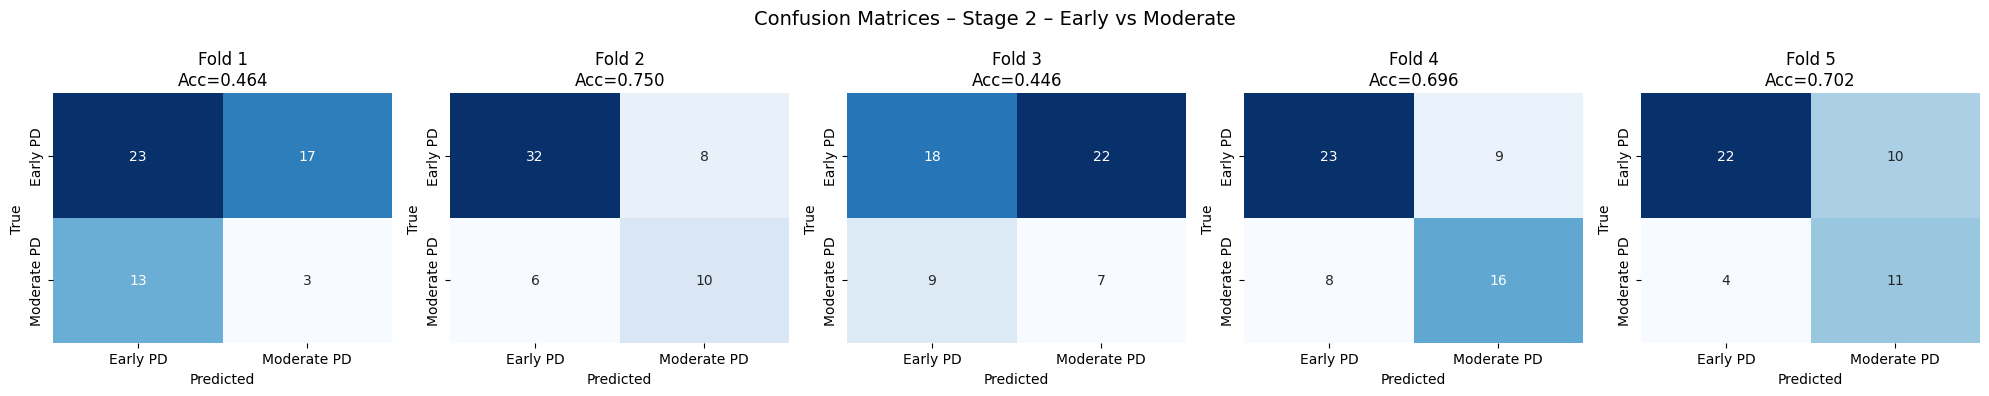

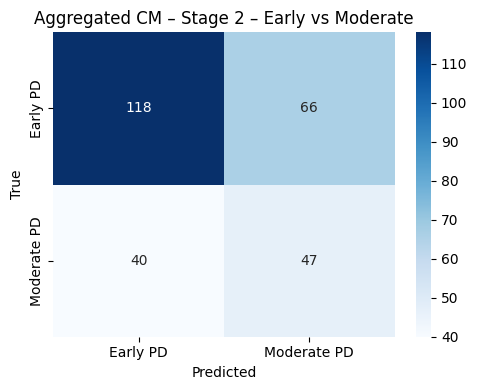

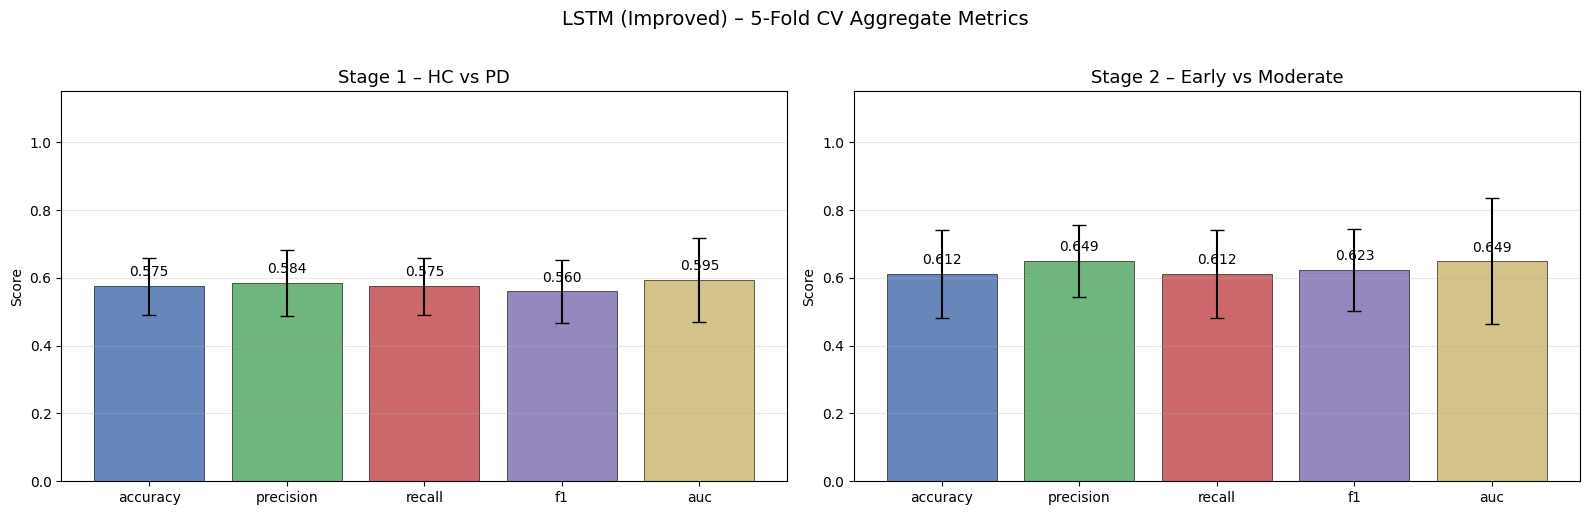


FINAL SUMMARY – LSTM (Path A, IMPROVED)

Stage 1 – HC vs PD
  accuracy    : 0.5753 ± 0.0835
  precision   : 0.5842 ± 0.0970
  recall      : 0.5753 ± 0.0835
  f1          : 0.5600 ± 0.0925
  auc         : 0.5945 ± 0.1236

Stage 2 – Early vs Moderate
  accuracy    : 0.6119 ± 0.1293
  precision   : 0.6492 ± 0.1067
  recall      : 0.6119 ± 0.1293
  f1          : 0.6231 ± 0.1213
  auc         : 0.6487 ± 0.1859

──────────────────────────────────────────────────────────────────────
FIT DIAGNOSIS VERDICTS:
──────────────────────────────────────────────────────────────────────
  Stage 1 – HC vs PD Fold 1: 🔴 SEVERE OVERFITTING
  Stage 1 – HC vs PD Fold 2: 🔴 SEVERE OVERFITTING
  Stage 1 – HC vs PD Fold 3: 🔴 SEVERE OVERFITTING
  Stage 1 – HC vs PD Fold 4: 🔴 SEVERE OVERFITTING
  Stage 1 – HC vs PD Fold 5: 🔴 SEVERE OVERFITTING
  Stage 2 – Early vs Moderate Fold 1: 🔴 SEVERE OVERFITTING
  Stage 2 – Early vs Moderate Fold 2: 🔴 SEVERE OVERFITTING
  Stage 2 – Early vs Moderate Fold 3: 🔴 SEVERE OVERFITT

In [8]:
### WITH FIT DIAGNOSIS — MATCHED TO ENHANCED PREPROCESSING

# ============================================================
# 19. IMPORTS FOR MODEL TRAINING
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ============================================================
# 20. LSTM MODEL DEFINITION (IMPROVED)
# ============================================================
# Key changes:
#   - Conv1D front-end to capture local temporal patterns (tremor)
#   - Reduced hidden_size (64 vs 128) — better for small datasets
#   - Multi-head attention pooling
#   - Residual connection around Conv block
#   - Accepts input_size=42 (21 features × 2 with multi-scale)
# ============================================================
class HandwritingLSTM(nn.Module):
    def __init__(
        self,
        input_size: int = 42,       # ← CHANGED: 21 features × 2 (multi-scale)
        hidden_size: int = 64,      # ← CHANGED: reduced from 128
        num_layers: int = 2,
        num_classes: int = 2,
        dropout: float = 0.4,       # ← CHANGED: increased from 0.3
        bidirectional: bool = True,
        use_conv_frontend: bool = True  # ← NEW
    ):
        super(HandwritingLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        self.use_conv_frontend = use_conv_frontend

        lstm_output_size = hidden_size * self.num_directions

        # ── NEW: Conv1D front-end ─────────────────────────────
        # Captures local temporal patterns (tremor frequency, pressure spikes)
        # before the LSTM sees the data
        if use_conv_frontend:
            self.conv_block = nn.Sequential(
                # First conv: wide kernel to capture tremor frequencies
                nn.Conv1d(input_size, 64, kernel_size=7, padding=3),
                nn.BatchNorm1d(64),
                nn.GELU(),
                # Second conv: medium kernel for acceleration patterns
                nn.Conv1d(64, 64, kernel_size=5, padding=2),
                nn.BatchNorm1d(64),
                nn.GELU(),
                # Project back to input_size for residual connection
                nn.Conv1d(64, input_size, kernel_size=3, padding=1),
                nn.BatchNorm1d(input_size),
                nn.GELU(),
                nn.Dropout(dropout / 2)
            )

        # ── LSTM backbone ─────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        # ── NEW: Multi-head attention pooling ─────────────────
        # Multiple attention heads capture different aspects:
        #   Head 1: might focus on high-jerk regions (tremor)
        #   Head 2: might focus on pressure anomalies
        #   Head 3: might focus on pauses/hesitations
        #   Head 4: might focus on velocity changes
        self.n_heads = 4
        self.attention_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(lstm_output_size, lstm_output_size // 4),
                nn.Tanh(),
                nn.Linear(lstm_output_size // 4, 1, bias=False)
            ) for _ in range(self.n_heads)
        ])

        # ── Classifier head ──────────────────────────────────
        classifier_input = lstm_output_size * self.n_heads  # Concat all heads
        self.classifier = nn.Sequential(
            nn.LayerNorm(classifier_input),
            nn.Dropout(dropout),
            nn.Linear(classifier_input, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size // 2, num_classes)
        )

    def multi_head_attention_pool(self, lstm_out, mask=None):
        """
        Apply multiple attention heads and concatenate contexts.
        Returns concatenated context and averaged attention weights.
        """
        contexts = []
        all_weights = []

        for head in self.attention_heads:
            attn_scores = head(lstm_out).squeeze(-1)      # (B, T)
            if mask is not None:
                attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))
            attn_weights = torch.softmax(attn_scores, dim=1)  # (B, T)
            context = torch.bmm(
                attn_weights.unsqueeze(1), lstm_out        # (B, 1, T) × (B, T, H)
            ).squeeze(1)                                    # (B, H)
            contexts.append(context)
            all_weights.append(attn_weights)

        # Concatenate all head contexts → (B, H × n_heads)
        multi_context = torch.cat(contexts, dim=-1)
        # Average attention weights for interpretability
        avg_weights = torch.stack(all_weights).mean(dim=0)

        return multi_context, avg_weights

    def forward(self, x, mask=None):
        # ── Conv1D front-end with residual ────────────────────
        if self.use_conv_frontend:
            # Conv1D expects (B, C, T), we have (B, T, C)
            x_conv = self.conv_block(x.transpose(1, 2)).transpose(1, 2)
            x = x + x_conv  # Residual connection

        # ── LSTM ──────────────────────────────────────────────
        lstm_out, _ = self.lstm(x)

        # ── Multi-head attention pooling ──────────────────────
        context, attn_weights = self.multi_head_attention_pool(lstm_out, mask)

        # ── Classification ────────────────────────────────────
        logits = self.classifier(context)

        return logits, attn_weights


# ============================================================
# 21. TRAINING UTILITIES
# ============================================================
class EarlyStopping:
    def __init__(self, patience: int = 10, min_delta: float = 1e-4,
                 mode: str = 'min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = {
                k: v.cpu().clone() for k, v in model.state_dict().items()
            }
        else:
            improved = (
                (score < self.best_score - self.min_delta) if self.mode == 'min'
                else (score > self.best_score + self.min_delta)
            )
            if improved:
                self.best_score = score
                self.counter = 0
                self.best_model_state = {
                    k: v.cpu().clone() for k, v in model.state_dict().items()
                }
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True

    def load_best(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)


def create_padding_mask(X: np.ndarray) -> np.ndarray:
    return (np.abs(X).sum(axis=-1) > 0).astype(np.float32)


def compute_class_weights(y: np.ndarray) -> torch.Tensor:
    classes, counts = np.unique(y, return_counts=True)
    total = len(y)
    weights = total / (len(classes) * counts)
    weight_tensor = torch.FloatTensor(weights)
    return weight_tensor


# ============================================================
# 22. FIT DIAGNOSIS FUNCTION (UNCHANGED)
# ============================================================
def diagnose_fit(
    history: dict,
    fold_idx: int = None,
    stage_name: str = "",
    gap_overfit_threshold: float = 0.15,
    gap_severe_overfit_threshold: float = 0.30,
    low_acc_threshold: float = 0.55,
    low_f1_threshold: float = 0.50,
    plateau_window: int = 10,
    plateau_delta: float = 0.005,
    loss_divergence_ratio: float = 2.0,
    val_loss_increase_window: int = 10,
    plot: bool = True
) -> dict:

    train_loss = np.array(history['train_loss'])
    val_loss   = np.array(history['val_loss'])
    train_acc  = np.array(history['train_acc'])
    val_acc    = np.array(history['val_acc'])
    val_f1     = np.array(history['val_f1'])

    n_epochs = len(train_loss)
    checks = {}
    recommendations = []
    details = {}

    fold_label = f"Fold {fold_idx + 1}" if fold_idx is not None else "Model"
    header = f"{stage_name} – {fold_label}" if stage_name else fold_label

    # CHECK 1: Accuracy Gap
    final_train_acc = float(np.mean(train_acc[-3:])) if n_epochs >= 3 else float(train_acc[-1])
    final_val_acc   = float(np.mean(val_acc[-3:]))   if n_epochs >= 3 else float(val_acc[-1])
    acc_gap = final_train_acc - final_val_acc

    details['final_train_acc'] = final_train_acc
    details['final_val_acc']   = final_val_acc
    details['acc_gap']         = acc_gap

    if acc_gap > gap_severe_overfit_threshold:
        checks['acc_gap'] = ('❌ SEVERE', f'Gap = {acc_gap:.4f} (>{gap_severe_overfit_threshold})')
        recommendations.append("🔴 Severe overfitting: Increase dropout, add L2 regularization, reduce model size, or augment data.")
    elif acc_gap > gap_overfit_threshold:
        checks['acc_gap'] = ('⚠️ OVERFIT', f'Gap = {acc_gap:.4f} (>{gap_overfit_threshold})')
        recommendations.append("🟡 Moderate overfitting: Consider increasing dropout, adding weight decay, or reducing hidden_size.")
    elif acc_gap < -0.05:
        checks['acc_gap'] = ('🔍 UNUSUAL', f'Gap = {acc_gap:.4f} (val > train)')
        recommendations.append("🔵 Val accuracy exceeds train — may indicate heavy regularization or small val set variance.")
    else:
        checks['acc_gap'] = ('✅ OK', f'Gap = {acc_gap:.4f}')

    # CHECK 2: Loss Gap
    final_train_loss = float(np.mean(train_loss[-3:])) if n_epochs >= 3 else float(train_loss[-1])
    final_val_loss   = float(np.mean(val_loss[-3:]))   if n_epochs >= 3 else float(val_loss[-1])
    loss_ratio = final_val_loss / max(final_train_loss, 1e-8)

    details['final_train_loss'] = final_train_loss
    details['final_val_loss']   = final_val_loss
    details['loss_ratio']       = loss_ratio

    if loss_ratio > loss_divergence_ratio:
        checks['loss_divergence'] = ('❌ DIVERGING', f'Ratio = {loss_ratio:.2f} (>{loss_divergence_ratio})')
        recommendations.append("🔴 Val loss is diverging from train loss — strong overfitting signal.")
    elif loss_ratio > 1.5:
        checks['loss_divergence'] = ('⚠️ WARNING', f'Ratio = {loss_ratio:.2f}')
        recommendations.append("🟡 Val loss notably higher than train loss — monitor for overfitting.")
    else:
        checks['loss_divergence'] = ('✅ OK', f'Ratio = {loss_ratio:.2f}')

    # CHECK 3: Absolute Performance
    final_f1 = float(np.mean(val_f1[-3:])) if n_epochs >= 3 else float(val_f1[-1])
    details['final_val_f1'] = final_f1
    underfit_signals = 0

    if final_val_acc < low_acc_threshold:
        checks['val_acc_level'] = ('❌ LOW', f'Val Acc = {final_val_acc:.4f} (<{low_acc_threshold})')
        underfit_signals += 1
        recommendations.append("🔴 Low validation accuracy — model may be underfitting.")
    else:
        checks['val_acc_level'] = ('✅ OK', f'Val Acc = {final_val_acc:.4f}')

    if final_f1 < low_f1_threshold:
        checks['val_f1_level'] = ('❌ LOW', f'Val F1 = {final_f1:.4f} (<{low_f1_threshold})')
        underfit_signals += 1
        recommendations.append("🔴 Low validation F1 — model struggles with at least one class.")
    else:
        checks['val_f1_level'] = ('✅ OK', f'Val F1 = {final_f1:.4f}')

    if final_train_acc < low_acc_threshold:
        checks['train_acc_level'] = ('❌ LOW', f'Train Acc = {final_train_acc:.4f} (<{low_acc_threshold})')
        underfit_signals += 1
        recommendations.append("🔴 Even training accuracy is low — model capacity may be insufficient.")
    else:
        checks['train_acc_level'] = ('✅ OK', f'Train Acc = {final_train_acc:.4f}')

    details['underfit_signals'] = underfit_signals

    # CHECK 4: Plateau Detection
    if n_epochs >= plateau_window:
        recent_val_loss = val_loss[-plateau_window:]
        val_loss_range = float(np.max(recent_val_loss) - np.min(recent_val_loss))
        details['plateau_range'] = val_loss_range
        if val_loss_range < plateau_delta:
            checks['plateau'] = ('⚠️ PLATEAU', f'Val loss range in last {plateau_window} epochs = {val_loss_range:.6f}')
            recommendations.append("🟡 Training has plateaued — consider reducing learning rate.")
        else:
            checks['plateau'] = ('✅ OK', f'Val loss range = {val_loss_range:.6f}')
    else:
        checks['plateau'] = ('ℹ️ SKIP', f'Only {n_epochs} epochs (need ≥{plateau_window})')

    # CHECK 5: Val Loss Trend
    if n_epochs >= val_loss_increase_window:
        recent = val_loss[-val_loss_increase_window:]
        x = np.arange(len(recent))
        slope = np.polyfit(x, recent, 1)[0]
        details['val_loss_slope'] = float(slope)
        if slope > 0.001:
            checks['val_loss_trend'] = ('⚠️ INCREASING', f'Slope = {slope:.6f}')
            recommendations.append("🟡 Validation loss is trending upward — overfitting is worsening.")
        elif slope < -0.001:
            checks['val_loss_trend'] = ('✅ DECREASING', f'Slope = {slope:.6f}')
        else:
            checks['val_loss_trend'] = ('✅ STABLE', f'Slope = {slope:.6f}')
    else:
        checks['val_loss_trend'] = ('ℹ️ SKIP', f'Only {n_epochs} epochs')

    # CHECK 6: Training Stability
    if n_epochs >= 10:
        recent_train = train_loss[-10:]
        oscillation = float(np.std(np.diff(recent_train)))
        details['train_loss_oscillation'] = oscillation
        if oscillation > 0.1:
            checks['stability'] = ('⚠️ UNSTABLE', f'Oscillation = {oscillation:.6f}')
            recommendations.append("🟡 Training loss is oscillating — consider lowering learning rate.")
        else:
            checks['stability'] = ('✅ STABLE', f'Oscillation = {oscillation:.6f}')
    else:
        checks['stability'] = ('ℹ️ SKIP', f'Only {n_epochs} epochs')

    # CHECK 7: Convergence Speed
    if n_epochs >= 5:
        best_val_epoch = int(np.argmin(val_loss)) + 1
        convergence_ratio = best_val_epoch / n_epochs
        details['best_val_epoch'] = best_val_epoch
        details['convergence_ratio'] = convergence_ratio
        if convergence_ratio < 0.2 and n_epochs > 30:
            checks['convergence'] = ('⚠️ EARLY PEAK', f'Best at epoch {best_val_epoch}/{n_epochs} ({convergence_ratio:.1%})')
            recommendations.append("🟡 Model peaked very early — subsequent training hurt val performance.")
        elif convergence_ratio > 0.95:
            checks['convergence'] = ('⚠️ STILL IMPROVING', f'Best at epoch {best_val_epoch}/{n_epochs}')
            recommendations.append("🟡 Best val score at the very end — model may benefit from more epochs.")
        else:
            checks['convergence'] = ('✅ OK', f'Best at epoch {best_val_epoch}/{n_epochs} ({convergence_ratio:.1%})')

    # OVERALL DIAGNOSIS
    severe_flags = sum(1 for v in checks.values() if '❌ SEVERE' in v[0])
    overfit_flags = sum(1 for v in checks.values() if 'OVERFIT' in v[0] or 'DIVERGING' in v[0])
    warning_flags = sum(1 for v in checks.values() if '⚠️' in v[0])

    if severe_flags > 0:
        status = '🔴 SEVERE OVERFITTING'
    elif underfit_signals >= 2:
        status = '🔴 UNDERFITTING'
    elif overfit_flags >= 2 or (overfit_flags >= 1 and warning_flags >= 2):
        status = '🟠 OVERFITTING'
    elif underfit_signals == 1 and acc_gap < 0.05:
        status = '🟡 MILD UNDERFITTING'
    elif warning_flags >= 2:
        status = '🟡 WARNING (potential issues)'
    elif overfit_flags == 1:
        status = '🟡 MILD OVERFITTING'
    else:
        status = '🟢 GOOD FIT'

    details['n_epochs'] = n_epochs
    if not recommendations:
        recommendations.append("✅ No major issues detected. Model appears well-fitted.")

    # PRINT REPORT
    print(f"\n{'─' * 65}")
    print(f"  FIT DIAGNOSIS: {header}")
    print(f"{'─' * 65}")
    print(f"  Status: {status}")
    print(f"  Epochs trained: {n_epochs}")
    print()
    print(f"  {'Check':<25s}  {'Result':<18s}  Detail")
    print(f"  {'─'*25}  {'─'*18}  {'─'*30}")
    for check_name, (result, detail) in checks.items():
        print(f"  {check_name:<25s}  {result:<18s}  {detail}")
    print(f"\n  Recommendations:")
    for rec in recommendations:
        print(f"    {rec}")
    print(f"{'─' * 65}")

    # DIAGNOSTIC PLOT
    if plot and n_epochs > 1:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'Fit Diagnosis – {header}\nStatus: {status}', fontsize=14, fontweight='bold')
        epochs = range(1, n_epochs + 1)

        ax = axes[0, 0]
        ax.plot(epochs, train_loss, label='Train Loss', color='#2196F3', linewidth=1.5)
        ax.plot(epochs, val_loss, label='Val Loss', color='#F44336', linewidth=1.5)
        ax.fill_between(epochs, train_loss, val_loss, alpha=0.15,
                        color='red' if acc_gap > gap_overfit_threshold else 'gray',
                        label='Gap (overfit zone)' if acc_gap > gap_overfit_threshold else 'Gap')
        if 'best_val_epoch' in details:
            ax.axvline(details['best_val_epoch'], color='green', linestyle='--', alpha=0.7,
                      label=f'Best val (epoch {details["best_val_epoch"]})')
        ax.set_title('Loss Curves')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = axes[0, 1]
        ax.plot(epochs, train_acc, label='Train Acc', color='#2196F3', linewidth=1.5)
        ax.plot(epochs, val_acc, label='Val Acc', color='#F44336', linewidth=1.5)
        ax.plot(epochs, val_f1, label='Val F1', color='#4CAF50', linewidth=1.5, linestyle='--')
        ax.axhline(low_acc_threshold, color='orange', linestyle=':', alpha=0.6,
                   label=f'Underfit threshold ({low_acc_threshold})')
        ax.fill_between(epochs, train_acc, val_acc, alpha=0.1, color='red')
        ax.set_title('Accuracy & F1 Curves')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score')
        ax.set_ylim([0, 1.05])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = axes[1, 0]
        loss_gap = val_loss - train_loss
        ax.plot(epochs, loss_gap, label='Loss Gap (val-train)', color='#9C27B0', linewidth=1.5)
        ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
        ax.fill_between(epochs, 0, loss_gap,
                        where=np.array(loss_gap) > 0, alpha=0.2, color='red', label='Overfit zone')
        ax.fill_between(epochs, 0, loss_gap,
                        where=np.array(loss_gap) <= 0, alpha=0.2, color='green', label='Underfit zone')
        ax.set_title('Generalization Gap (Loss)')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Val Loss − Train Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = axes[1, 1]
        summary_metrics = {
            'Train Acc': final_train_acc,
            'Val Acc': final_val_acc,
            'Val F1': final_f1,
            'Acc Gap': acc_gap,
            'Loss Ratio': min(loss_ratio, 3.0) / 3.0
        }
        colors_map = []
        for k, v in summary_metrics.items():
            if k == 'Acc Gap':
                colors_map.append('#F44336' if v > gap_overfit_threshold else '#4CAF50')
            elif k == 'Loss Ratio':
                colors_map.append('#F44336' if loss_ratio > loss_divergence_ratio else '#4CAF50')
            elif k in ['Val Acc', 'Val F1']:
                colors_map.append('#F44336' if v < low_acc_threshold else '#4CAF50')
            else:
                colors_map.append('#2196F3')
        bars = ax.barh(list(summary_metrics.keys()), list(summary_metrics.values()),
                       color=colors_map, alpha=0.8, edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, summary_metrics.values()):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{val:.4f}', va='center', fontsize=9)
        ax.set_title('Key Metrics Summary')
        ax.set_xlim([0, 1.2])
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        'status': status,
        'checks': checks,
        'recommendations': recommendations,
        'details': details
    }


# ============================================================
# 23. BATCH DIAGNOSIS (all folds, all stages) — UNCHANGED
# ============================================================
def diagnose_all_folds(all_results, stages_cfg, plot_per_fold=True, plot_summary=True):
    all_diagnoses = {}

    for stage_name, _, _, class_names in stages_cfg:
        if stage_name not in all_results:
            continue

        fold_results = all_results[stage_name]['fold_results']
        stage_diagnoses = []

        print("\n" + "=" * 70)
        print(f"  FIT DIAGNOSIS REPORT: {stage_name}")
        print("=" * 70)

        for fold_idx, result in enumerate(fold_results):
            diag = diagnose_fit(
                history=result['history'],
                fold_idx=fold_idx,
                stage_name=stage_name,
                plot=plot_per_fold
            )
            stage_diagnoses.append(diag)

        all_diagnoses[stage_name] = stage_diagnoses

        print(f"\n{'═' * 65}")
        print(f"  STAGE SUMMARY: {stage_name}")
        print(f"{'═' * 65}")

        statuses = [d['status'] for d in stage_diagnoses]
        status_counts = defaultdict(int)
        for s in statuses:
            status_counts[s] += 1

        print(f"\n  Fold Status Distribution:")
        for status, count in sorted(status_counts.items(), key=lambda x: -x[1]):
            bar = '█' * count
            print(f"    {status:<40s}  {count}/{len(statuses)}  {bar}")

        acc_gaps = [d['details']['acc_gap'] for d in stage_diagnoses]
        val_accs = [d['details']['final_val_acc'] for d in stage_diagnoses]
        val_f1s  = [d['details']['final_val_f1'] for d in stage_diagnoses]

        print(f"\n  Across Folds:")
        print(f"    Acc Gap:  mean={np.mean(acc_gaps):.4f}  std={np.std(acc_gaps):.4f}  "
              f"range=[{np.min(acc_gaps):.4f}, {np.max(acc_gaps):.4f}]")
        print(f"    Val Acc:  mean={np.mean(val_accs):.4f}  std={np.std(val_accs):.4f}")
        print(f"    Val F1:   mean={np.mean(val_f1s):.4f}   std={np.std(val_f1s):.4f}")

        overfit_count = sum(1 for s in statuses if 'OVERFIT' in s.upper())
        underfit_count = sum(1 for s in statuses if 'UNDERFIT' in s.upper())
        good_count = sum(1 for s in statuses if 'GOOD' in s.upper())

        if overfit_count >= 3:
            stage_verdict = '🔴 PREDOMINANTLY OVERFITTING'
        elif underfit_count >= 3:
            stage_verdict = '🔴 PREDOMINANTLY UNDERFITTING'
        elif good_count >= 3:
            stage_verdict = '🟢 PREDOMINANTLY GOOD FIT'
        elif overfit_count >= 2:
            stage_verdict = '🟠 TENDENCY TO OVERFIT'
        elif underfit_count >= 2:
            stage_verdict = '🟠 TENDENCY TO UNDERFIT'
        else:
            stage_verdict = '🟡 MIXED RESULTS'

        print(f"\n  ➤ Stage Verdict: {stage_verdict}")
        print(f"{'═' * 65}")

    if plot_summary:
        _plot_diagnosis_summary(all_diagnoses, stages_cfg)

    return all_diagnoses


def _plot_diagnosis_summary(all_diagnoses, stages_cfg):
    fig, axes = plt.subplots(1, len(all_diagnoses), figsize=(7 * len(all_diagnoses), 5))
    if len(all_diagnoses) == 1:
        axes = [axes]

    color_map = {
        'GOOD': '#4CAF50', 'MILD OVERFIT': '#FFC107', 'OVERFIT': '#FF9800',
        'SEVERE OVERFIT': '#F44336', 'UNDERFIT': '#2196F3',
        'MILD UNDERFIT': '#03A9F4', 'WARNING': '#9E9E9E', 'MIXED': '#9C27B0'
    }

    for idx, (stage_name, _, _, _) in enumerate(stages_cfg):
        if stage_name not in all_diagnoses:
            continue
        diagnoses = all_diagnoses[stage_name]
        ax = axes[idx]

        categories = []
        for d in diagnoses:
            s = d['status'].upper()
            if 'SEVERE' in s:
                categories.append('SEVERE OVERFIT')
            elif 'UNDERFITTING' in s and 'MILD' in s:
                categories.append('MILD UNDERFIT')
            elif 'UNDERFITTING' in s:
                categories.append('UNDERFIT')
            elif 'OVERFITTING' in s and 'MILD' in s:
                categories.append('MILD OVERFIT')
            elif 'OVERFITTING' in s:
                categories.append('OVERFIT')
            elif 'GOOD' in s:
                categories.append('GOOD')
            elif 'WARNING' in s:
                categories.append('WARNING')
            else:
                categories.append('MIXED')

        cat_counts = defaultdict(int)
        for c in categories:
            cat_counts[c] += 1

        labels = list(cat_counts.keys())
        counts = list(cat_counts.values())
        colors = [color_map.get(l, '#9E9E9E') for l in labels]

        ax.bar(labels, counts, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
        for i, (lbl, cnt) in enumerate(zip(labels, counts)):
            ax.text(i, cnt + 0.05, str(cnt), ha='center', fontweight='bold')
        ax.set_title(stage_name, fontsize=12)
        ax.set_ylabel('Number of Folds')
        ax.set_ylim([0, max(counts) + 1])
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Fit Diagnosis Summary Across Folds', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================================
# 24. TRAINING LOOP (IMPROVED)
# ============================================================
# Key changes:
#   - ReduceLROnPlateau instead of CosineAnnealingWarmRestarts
#   - Warmup phase (first 10 epochs)
#   - Label smoothing in loss function
#   - Mixup augmentation during training
#   - Increased patience and max_epochs
# ============================================================
def train_lstm_fold(
    fold_data: dict,
    input_size: int = 42,       # ← CHANGED
    hidden_size: int = 64,      # ← CHANGED
    num_layers: int = 2,
    num_classes: int = 2,
    dropout: float = 0.4,       # ← CHANGED
    bidirectional: bool = True,
    lr: float = 1e-3,           # ← CHANGED
    weight_decay: float = 5e-4, # ← CHANGED
    batch_size: int = 16,       # ← CHANGED
    max_epochs: int = 300,      # ← CHANGED
    patience: int = 25,         # ← CHANGED
    class_names: list = None,
    use_mixup: bool = True,     # ← NEW
    mixup_alpha: float = 0.2,   # ← NEW
    warmup_epochs: int = 10,    # ← NEW
    label_smoothing: float = 0.1  # ← NEW
) -> dict:

    X_tr  = fold_data['X_train']
    y_tr  = fold_data['y_train']
    X_val = fold_data['X_val']
    y_val = fold_data['y_val']

    mask_tr  = create_padding_mask(X_tr)
    mask_val = create_padding_mask(X_val)

    X_tr_t  = torch.FloatTensor(X_tr).to(device)
    y_tr_t  = torch.LongTensor(y_tr).to(device)
    m_tr_t  = torch.FloatTensor(mask_tr).to(device)

    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)
    m_val_t = torch.FloatTensor(mask_val).to(device)

    train_ds = TensorDataset(X_tr_t, y_tr_t, m_tr_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              drop_last=False)

    # ── Model ─────────────────────────────────────────────────
    model = HandwritingLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=num_classes,
        dropout=dropout,
        bidirectional=bidirectional,
        use_conv_frontend=True      # ← NEW
    ).to(device)

    # ── Print model size ──────────────────────────────────────
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"    Model parameters: {n_params:,}")

    # ── Loss with label smoothing and class weights ───────────
    class_weights = compute_class_weights(y_tr).to(device)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=label_smoothing    # ← NEW
    )

    # ── Optimizer ─────────────────────────────────────────────
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # ── NEW: Warmup + ReduceLROnPlateau ───────────────────────
    # Phase 1: Linear warmup (epochs 0 to warmup_epochs)
    # Phase 2: ReduceLROnPlateau (reacts to actual val loss)
    warmup_scheduler = optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=0.1,
        end_factor=1.0,
        total_iters=warmup_epochs
    )
    plateau_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
    )

    early_stop = EarlyStopping(patience=patience, mode='min')

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'val_f1': [], 'lr': []
    }

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_correct = 0
        epoch_total = 0

        for batch_X, batch_y, batch_m in train_loader:

            # ── NEW: Mixup augmentation (after warmup) ────────
            if use_mixup and epoch >= warmup_epochs and batch_X.size(0) > 1:
                lam = np.random.beta(mixup_alpha, mixup_alpha)
                lam = max(lam, 1 - lam)  # Ensure lam >= 0.5

                idx = torch.randperm(batch_X.size(0)).to(device)
                mixed_X = lam * batch_X + (1 - lam) * batch_X[idx]

                optimizer.zero_grad()
                logits, _ = model(mixed_X, batch_m)
                loss = lam * criterion(logits, batch_y) + \
                       (1 - lam) * criterion(logits, batch_y[idx])
            else:
                optimizer.zero_grad()
                logits, _ = model(batch_X, batch_m)
                loss = criterion(logits, batch_y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item() * batch_X.size(0)
            preds = logits.argmax(dim=1)
            epoch_correct += (preds == batch_y).sum().item()
            epoch_total += batch_X.size(0)

        # ── Scheduler step ────────────────────────────────────
        if epoch < warmup_epochs:
            warmup_scheduler.step()
        # plateau_scheduler steps after validation (below)

        train_loss = epoch_loss / epoch_total
        train_acc = epoch_correct / epoch_total

        # ── Validation ────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_logits, _ = model(X_val_t, m_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
            val_preds = val_logits.argmax(dim=1).cpu().numpy()
            val_probs = torch.softmax(val_logits, dim=1).cpu().numpy()

        val_acc = accuracy_score(y_val, val_preds)
        val_f1  = f1_score(y_val, val_preds, average='weighted')

        # ── ReduceLROnPlateau steps on val_loss ───────────────
        if epoch >= warmup_epochs:
            plateau_scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        early_stop(val_loss, model)
        if early_stop.early_stop:
            print(f"    Early stop at epoch {epoch + 1}")
            break

        if (epoch + 1) % 10 == 0 or epoch == 0:
            phase = "WARMUP" if epoch < warmup_epochs else "TRAIN"
            print(f"    Epoch {epoch+1:>4d} [{phase:>6s}] │ "
                  f"loss: {train_loss:.4f}/{val_loss:.4f}  "
                  f"acc: {train_acc:.3f}/{val_acc:.3f}  "
                  f"F1: {val_f1:.3f}  "
                  f"lr: {optimizer.param_groups[0]['lr']:.2e}")

    # ── Load best model and evaluate ──────────────────────────
    early_stop.load_best(model)
    model.eval()
    with torch.no_grad():
        val_logits, val_attn = model(X_val_t, m_val_t)
        val_preds = val_logits.argmax(dim=1).cpu().numpy()
        val_probs = torch.softmax(val_logits, dim=1).cpu().numpy()

    metrics = {
        'accuracy':  accuracy_score(y_val, val_preds),
        'precision': precision_score(y_val, val_preds, average='weighted', zero_division=0),
        'recall':    recall_score(y_val, val_preds, average='weighted', zero_division=0),
        'f1':        f1_score(y_val, val_preds, average='weighted', zero_division=0),
        'confusion_matrix': confusion_matrix(y_val, val_preds),
    }

    try:
        if num_classes == 2:
            metrics['auc'] = roc_auc_score(y_val, val_probs[:, 1])
        else:
            metrics['auc'] = roc_auc_score(y_val, val_probs, multi_class='ovr')
    except ValueError:
        metrics['auc'] = float('nan')

    return {
        'model': model,
        'metrics': metrics,
        'history': history,
        'val_preds': val_preds,
        'val_probs': val_probs,
        'val_true': y_val,
        'best_epoch': len(history['train_loss']) - early_stop.counter
    }


# ============================================================
# 25. HYPERPARAMETERS (IMPROVED)
# ============================================================
# ── Determine input size based on preprocessing config ────────
if USE_MULTI_SCALE:
    LSTM_INPUT_SIZE = len(FEATURES) * 2   # 21 × 2 = 42
else:
    LSTM_INPUT_SIZE = len(FEATURES)       # 21

LSTM_CONFIG = {
    'input_size':      LSTM_INPUT_SIZE,   # ← CHANGED: 42 (or 21)
    'hidden_size':     64,                # ← CHANGED: reduced from 128
    'num_layers':      2,
    'dropout':         0.4,               # ← CHANGED: increased from 0.3
    'bidirectional':   True,
    'lr':              1e-3,              # ← CHANGED: increased from 5e-4
    'weight_decay':    5e-4,              # ← CHANGED: increased from 1e-4
    'batch_size':      16,                # ← CHANGED: reduced from 32
    'max_epochs':      300,               # ← CHANGED: increased from 150
    'patience':        25,                # ← CHANGED: increased from 15
    'use_mixup':       True,              # ← NEW
    'mixup_alpha':     0.2,               # ← NEW
    'warmup_epochs':   10,                # ← NEW
    'label_smoothing': 0.1,               # ← NEW
}

print("\n" + "=" * 55)
print("  LSTM Configuration (IMPROVED)")
print("=" * 55)
for k, v in LSTM_CONFIG.items():
    print(f"  {k:<18s}: {v}")

# Print what changed
print(f"\n  Changes from previous config:")
print(f"    input_size:    4 → {LSTM_INPUT_SIZE}  (21 features × {'2 multi-scale' if USE_MULTI_SCALE else '1'})")
print(f"    hidden_size:   128 → 64  (reduced for small dataset)")
print(f"    dropout:       0.3 → 0.4  (increased regularization)")
print(f"    lr:            5e-4 → 1e-3  (model was not learning)")
print(f"    weight_decay:  1e-4 → 5e-4  (stronger L2 reg)")
print(f"    batch_size:    32 → 16  (more gradient updates)")
print(f"    max_epochs:    150 → 300  (model was stopping too early)")
print(f"    patience:      15 → 25  (give model more time)")
print(f"    NEW: Conv1D front-end, multi-head attention, mixup, warmup, label smoothing")


# ============================================================
# 26. RUN 5-FOLD CV FOR BOTH STAGES (UPDATED)
# ============================================================
all_results = {}

for stage_name, subj_df, label_map, class_names in stages_cfg:
    num_classes = len(class_names)

    print("\n" + "=" * 70)
    print(f"  LSTM (IMPROVED) – {stage_name}  ({' vs '.join(class_names)})")
    print("=" * 70)

    fold_results = []
    aggregate_metrics = defaultdict(list)

    for fold_idx in range(N_FOLDS):
        print(f"\n  ── Fold {fold_idx + 1}/{N_FOLDS} ──")

        # ── CHANGED: get_path_a_fold_binary now includes ──────
        # enhanced features, downsampling, and augmentation
        fold_data = get_path_a_fold_binary(
            fold_idx, full_df, subj_df, label_map, SEQUENCE_LENGTH,
            augment=True,       # ← NEW: enable augmentation
            aug_factor=3        # ← NEW: 3× augmentation
        )

        print(f"    Train: {fold_data['X_train'].shape}  "
              f"Val: {fold_data['X_val'].shape}")
        print(f"    Train dist: {dict(zip(*np.unique(fold_data['y_train'], return_counts=True)))}")
        print(f"    Val   dist: {dict(zip(*np.unique(fold_data['y_val'], return_counts=True)))}")

        result = train_lstm_fold(
            fold_data,
            num_classes=num_classes,
            class_names=class_names,
            **LSTM_CONFIG
        )

        fold_results.append(result)

        m = result['metrics']
        print(f"\n    ✅ Best epoch: {result['best_epoch']}")
        print(f"    Accuracy : {m['accuracy']:.4f}")
        print(f"    Precision: {m['precision']:.4f}")
        print(f"    Recall   : {m['recall']:.4f}")
        print(f"    F1       : {m['f1']:.4f}")
        print(f"    AUC      : {m['auc']:.4f}")

        for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
            aggregate_metrics[metric_name].append(m[metric_name])

    # Aggregate
    print(f"\n{'─' * 70}")
    print(f"  AGGREGATE – {stage_name}")
    print(f"{'─' * 70}")
    print(f"  {'Metric':<12s}  {'Mean':>8s}  {'Std':>8s}  {'Min':>8s}  {'Max':>8s}")
    print(f"  {'─'*12}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}")

    for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
        vals = aggregate_metrics[metric_name]
        vals_clean = [v for v in vals if not np.isnan(v)]
        if vals_clean:
            print(f"  {metric_name:<12s}  {np.mean(vals_clean):>8.4f}  "
                  f"{np.std(vals_clean):>8.4f}  "
                  f"{np.min(vals_clean):>8.4f}  {np.max(vals_clean):>8.4f}")

    all_results[stage_name] = {
        'fold_results': fold_results,
        'aggregate': dict(aggregate_metrics)
    }


# ============================================================
# 27. RUN FIT DIAGNOSIS ON ALL RESULTS
# ============================================================
print("\n" + "=" * 70)
print("  RUNNING FIT DIAGNOSIS ON ALL FOLDS")
print("=" * 70)

all_diagnoses = diagnose_all_folds(
    all_results,
    stages_cfg,
    plot_per_fold=True,
    plot_summary=True
)


# ============================================================
# 28. VISUALIZATION – TRAINING CURVES
# ============================================================
def plot_training_curves(all_results, stages_cfg):
    for stage_name, _, _, class_names in stages_cfg:
        if stage_name not in all_results:
            continue

        fold_results = all_results[stage_name]['fold_results']
        n_folds = len(fold_results)

        fig, axes = plt.subplots(2, n_folds, figsize=(5 * n_folds, 8))
        fig.suptitle(f'LSTM Training Curves – {stage_name}', fontsize=14, y=1.02)

        for i, result in enumerate(fold_results):
            h = result['history']
            epochs = range(1, len(h['train_loss']) + 1)

            ax = axes[0, i] if n_folds > 1 else axes[0]
            ax.plot(epochs, h['train_loss'], label='Train', alpha=0.8)
            ax.plot(epochs, h['val_loss'], label='Val', alpha=0.8)
            if result['best_epoch'] is not None:
                ax.axvline(result['best_epoch'], color='red', linestyle='--',
                          alpha=0.5, label=f"Best ({result['best_epoch']})")
            ax.set_title(f'Fold {i+1} – Loss')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

            ax = axes[1, i] if n_folds > 1 else axes[1]
            ax.plot(epochs, h['train_acc'], label='Train', alpha=0.8)
            ax.plot(epochs, h['val_acc'], label='Val', alpha=0.8)
            ax.plot(epochs, h['val_f1'], label='Val F1', alpha=0.8, linestyle='--')
            ax.set_title(f'Fold {i+1} – Accuracy & F1')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Score')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])

        plt.tight_layout()
        plt.show()

plot_training_curves(all_results, stages_cfg)


# ============================================================
# 29. VISUALIZATION – CONFUSION MATRICES
# ============================================================
def plot_confusion_matrices(all_results, stages_cfg):
    for stage_name, _, _, class_names in stages_cfg:
        if stage_name not in all_results:
            continue

        fold_results = all_results[stage_name]['fold_results']
        n_folds = len(fold_results)

        fig, axes = plt.subplots(1, n_folds, figsize=(4 * n_folds, 4))
        fig.suptitle(f'Confusion Matrices – {stage_name}', fontsize=14)

        for i, result in enumerate(fold_results):
            ax = axes[i] if n_folds > 1 else axes
            cm = result['metrics']['confusion_matrix']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=class_names, yticklabels=class_names,
                       ax=ax, cbar=False)
            ax.set_title(f'Fold {i+1}\nAcc={result["metrics"]["accuracy"]:.3f}')
            ax.set_ylabel('True')
            ax.set_xlabel('Predicted')

        plt.tight_layout()
        plt.show()

        all_true = np.concatenate([r['val_true'] for r in fold_results])
        all_pred = np.concatenate([r['val_preds'] for r in fold_results])
        cm_agg = confusion_matrix(all_true, all_pred)

        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        sns.heatmap(cm_agg, annot=True, fmt='d', cmap='Blues',
                   xticklabels=class_names, yticklabels=class_names,
                   ax=ax, cbar=True)
        ax.set_title(f'Aggregated CM – {stage_name}')
        ax.set_ylabel('True')
        ax.set_xlabel('Predicted')
        plt.tight_layout()
        plt.show()

plot_confusion_matrices(all_results, stages_cfg)


# ============================================================
# 30. AGGREGATE METRIC BAR CHART
# ============================================================
def plot_aggregate_bar(all_results, stages_cfg):
    metric_names = ['accuracy', 'precision', 'recall', 'f1', 'auc']

    fig, axes = plt.subplots(1, len(stages_cfg), figsize=(8 * len(stages_cfg), 5))
    if len(stages_cfg) == 1:
        axes = [axes]

    for idx, (stage_name, _, _, class_names) in enumerate(stages_cfg):
        if stage_name not in all_results:
            continue
        agg = all_results[stage_name]['aggregate']
        means = [np.nanmean(agg[m]) for m in metric_names]
        stds  = [np.nanstd(agg[m]) for m in metric_names]

        ax = axes[idx]
        bars = ax.bar(metric_names, means, yerr=stds, capsize=5,
                      color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'],
                      alpha=0.85, edgecolor='black', linewidth=0.5)

        for bar, mean_val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                   f'{mean_val:.3f}', ha='center', va='bottom', fontsize=10)

        ax.set_title(f'{stage_name}', fontsize=13)
        ax.set_ylim([0, 1.15])
        ax.set_ylabel('Score')
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('LSTM (Improved) – 5-Fold CV Aggregate Metrics', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_aggregate_bar(all_results, stages_cfg)


# ============================================================
# 31. FINAL SUMMARY TABLE
# ============================================================
print("\n" + "=" * 70)
print("FINAL SUMMARY – LSTM (Path A, IMPROVED)")
print("=" * 70)

summary_rows = []
for stage_name, _, _, class_names in stages_cfg:
    if stage_name not in all_results:
        continue
    agg = all_results[stage_name]['aggregate']
    row = {'Stage': stage_name}
    for m in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
        vals = [v for v in agg[m] if not np.isnan(v)]
        if vals:
            row[f'{m}_mean'] = np.mean(vals)
            row[f'{m}_std']  = np.std(vals)
        else:
            row[f'{m}_mean'] = np.nan
            row[f'{m}_std']  = np.nan
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

for _, row in summary_df.iterrows():
    print(f"\n{row['Stage']}")
    for m in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
        mean_val = row[f'{m}_mean']
        std_val  = row[f'{m}_std']
        print(f"  {m:<12s}: {mean_val:.4f} ± {std_val:.4f}")

# Print diagnosis verdicts
print(f"\n{'─' * 70}")
print("FIT DIAGNOSIS VERDICTS:")
print(f"{'─' * 70}")
for stage_name in all_diagnoses:
    diagnoses = all_diagnoses[stage_name]
    for i, d in enumerate(diagnoses):
        print(f"  {stage_name} Fold {i+1}: {d['status']}")

print("\n✅ LSTM training + fit diagnosis complete (IMPROVED pipeline).")


# ============================================================
# 32. SAVE MODELS
# ============================================================
SAVE_DIR = '/content/drive/MyDrive/teasis/PaHaW/models/'
os.makedirs(SAVE_DIR, exist_ok=True)

for stage_name in all_results:
    fold_results = all_results[stage_name]['fold_results']
    best_fold_idx = np.argmax([r['metrics']['f1'] for r in fold_results])
    best_model = fold_results[best_fold_idx]['model']

    safe_name = stage_name.replace(' ', '_').replace('–', '').replace('__', '_')
    save_path = os.path.join(SAVE_DIR, f'lstm_improved_{safe_name}_best_fold{best_fold_idx+1}.pt')

    diag = all_diagnoses.get(stage_name, [{}] * N_FOLDS)[best_fold_idx]

    torch.save({
        'model_state_dict': best_model.state_dict(),
        'config': LSTM_CONFIG,
        'metrics': fold_results[best_fold_idx]['metrics'],
        'stage_name': stage_name,
        'fold_idx': best_fold_idx,
        'fit_diagnosis': diag.get('status', 'N/A'),
        'preprocessing': {
            'features': FEATURES,
            'features_lstm': FEATURES_LSTM,
            'sequence_length': SEQUENCE_LENGTH,
            'use_multi_scale': USE_MULTI_SCALE,
            'augmentation_factor': 3,
        }
    }, save_path)

    print(f"Saved: {save_path}")
    print(f"  Best fold: {best_fold_idx + 1}  "
          f"F1: {fold_results[best_fold_idx]['metrics']['f1']:.4f}  "
          f"AUC: {fold_results[best_fold_idx]['metrics']['auc']:.4f}  "
          f"Fit: {diag.get('status', 'N/A')}")

print("\n✅ All models saved.")

In [6]:
# ============================================================
# COMPUTE AVERAGE SEQUENCE LENGTH PER TASK
# ============================================================

# Step 1: Compute length of each individual recording (subject × task)
seq_lengths = []

for (subj_id, task), group in full_df.groupby(['subject_id', 'task']):
    seq_lengths.append({
        'subject_id': subj_id,
        'task': task,
        'length': len(group)
    })

seq_len_df = pd.DataFrame(seq_lengths)

print("=" * 70)
print("SEQUENCE LENGTH ANALYSIS")
print("=" * 70)

# Step 2: Verify 8 tasks per subject
tasks_per_subject = seq_len_df.groupby('subject_id')['task'].nunique()
print(f"\nTasks per subject distribution:")
print(tasks_per_subject.value_counts().sort_index())
print(f"Subjects with exactly 8 tasks: {(tasks_per_subject == 8).sum()} / {len(tasks_per_subject)}")

# Step 3: Per-task statistics across all subjects
print(f"\n{'─' * 70}")
print(f"{'Task':<10} {'Count':>8} {'Mean':>10} {'Median':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print(f"{'─' * 70}")

task_avg_lengths = {}
for task in sorted(seq_len_df['task'].unique()):
    task_data = seq_len_df[seq_len_df['task'] == task]['length']
    task_avg_lengths[task] = task_data.mean()
    print(f"{task:<10} {len(task_data):>8} {task_data.mean():>10.1f} {task_data.median():>10.1f} "
          f"{task_data.std():>10.1f} {task_data.min():>10} {task_data.max():>10}")

print(f"{'─' * 70}")

# Step 4: Overall average across all recordings
overall_mean = seq_len_df['length'].mean()
overall_median = seq_len_df['length'].median()
print(f"\n{'Overall':<10} {len(seq_len_df):>8} {overall_mean:>10.1f} {overall_median:>10.1f} "
      f"{seq_len_df['length'].std():>10.1f} {seq_len_df['length'].min():>10} {seq_len_df['length'].max():>10}")

# Step 5: Compute per-task average sequence length (to be used as SEQUENCE_LENGTH per task)
print(f"\n{'=' * 70}")
print("AVERAGE SEQUENCE LENGTH PER TASK (rounded to nearest integer)")
print(f"{'=' * 70}")

TASK_SEQUENCE_LENGTHS = {}
for task in sorted(seq_len_df['task'].unique()):
    avg_len = int(round(seq_len_df[seq_len_df['task'] == task]['length'].mean()))
    TASK_SEQUENCE_LENGTHS[task] = avg_len
    print(f"  Task {task}: {avg_len}")

print(f"\nTASK_SEQUENCE_LENGTHS = {TASK_SEQUENCE_LENGTHS}")

# Step 6: Show per-subject breakdown (first 5 subjects as sample)
print(f"\n{'=' * 70}")
print("PER-SUBJECT SEQUENCE LENGTHS (first 5 subjects)")
print(f"{'=' * 70}")

sample_subjects = sorted(seq_len_df['subject_id'].unique())[:98]
for sid in sample_subjects:
    subj_data = seq_len_df[seq_len_df['subject_id'] == sid].sort_values('task')
    lengths = subj_data.set_index('task')['length'].to_dict()
    print(f"\n  Subject {sid}:")
    for task in sorted(lengths.keys()):
        avg_for_task = TASK_SEQUENCE_LENGTHS[task]
        diff = lengths[task] - avg_for_task
        print(f"    Task {task}: {lengths[task]:>8} samples  (avg for task: {avg_for_task}, diff: {diff:+d})")

# Step 7: Update the regularize_sequence function to use per-task lengths
print(f"\n{'=' * 70}")
print("UPDATED SEQUENCE REGULARIZATION")
print(f"{'=' * 70}")

def regularize_sequence(seq: np.ndarray, target_len: int) -> np.ndarray:
    """Clip or zero-pad to target_len. No downsampling."""
    T, n_feat = seq.shape
    if T >= target_len:
        return seq[:target_len, :]
    else:
        pad = np.zeros((target_len - T, n_feat), dtype=seq.dtype)
        return np.vstack([seq, pad])

# Step 8: Show coverage statistics (what % of data is retained vs padded)
print(f"\n{'─' * 70}")
print(f"{'Task':<10} {'Avg Len':>10} {'% Clipped':>12} {'% Padded':>12} {'% Exact':>12}")
print(f"{'─' * 70}")

for task in sorted(TASK_SEQUENCE_LENGTHS.keys()):
    target = TASK_SEQUENCE_LENGTHS[task]
    task_data = seq_len_df[seq_len_df['task'] == task]['length']
    n_clipped = (task_data > target).sum()
    n_padded = (task_data < target).sum()
    n_exact = (task_data == target).sum()
    total = len(task_data)
    print(f"{task:<10} {target:>10} {100*n_clipped/total:>11.1f}% {100*n_padded/total:>11.1f}% {100*n_exact/total:>11.1f}%")

print(f"\n✅ Task-specific sequence lengths computed.")
print(f"   Use TASK_SEQUENCE_LENGTHS dict when building Path A sequences.")

SEQUENCE LENGTH ANALYSIS

Tasks per subject distribution:
task
7     3
8    69
Name: count, dtype: int64
Subjects with exactly 8 tasks: 69 / 72

──────────────────────────────────────────────────────────────────────
Task          Count       Mean     Median        Std        Min        Max
──────────────────────────────────────────────────────────────────────
1                69     2907.0     2339.0     2289.6        552      16071
2                72     1656.8     1479.5      714.6        405       4226
3                72     1980.8     1776.5      988.3        808       6615
4                72     2253.9     2113.5     1030.8        614       6827
5                72     2561.5     2212.0     1193.9        855       6661
6                72     2290.2     2058.5      969.5        895       5783
7                72     1475.2     1315.5      656.1        585       4423
8                72     3104.0     2824.5     1171.1       1234       7676
──────────────────────────────────────